# 1. Kernel Monte Carlo

In this notebook, the design and implementation of the GPU kernels used in Pyroclast for Monte Carlo simulations are presented. A single synthetic habitat and invasion map based on a Digital Elevation Model (DEM) is generated at the start, and each GPU adapter is run on this shared data to compare execution times and verify outputs.

### Setup: Synthetic Data Generation
First, a synthetic Digital Elevation Model (DEM) is generated and the `generate_synthetic_habitat_dem` service from the `pyroclast` library is used to create a realistic habitat and invasion map. This data is reused across all subsequent examples.


In [ ]:
import numpy as np
from pyroclast import generate_synthetic_habitat_dem, CompactedHabitat, SpatialHabitat
from pyroclast.domain.models import MonteCarloConfig

# 1. Create a dummy elevation model (DEM)
shape = (50, 50)
np.random.seed(42)
dem = np.random.uniform(100, 1000, shape).astype(np.float32)

# 2. Generate a synthetic habitat map and invasion map from the DEM
# We target 20% occupancy and 20% average invasion probability
habitat_map, invasion_map = generate_synthetic_habitat_dem(
    dem=dem,
    occupancy_fraction=0.20,
    mean_p=0.20,
    seed=42,
    habitat_code="SYNTH_DEM",
    threshold=0.15 # theta
)

# 3. Prepare the CompactedHabitat (used by 1D/2D adapters)
presence = habitat_map.data  # 2D uint8 presence mask
p_map = invasion_map.data    # 2D float32 invasion probability map

p_vec = p_map[presence == 1].astype(np.float32)
n_cells = len(p_vec)

compacted_habitat = CompactedHabitat(
    habitat_code=habitat_map.code,
    n_cells=n_cells,
    p_vec=p_vec
)

# 4. Prepare the SpatialHabitat (used by Map-Centric adapter)
spatial_habitat = SpatialHabitat(
    habitat_code=habitat_map.code,
    presence_mask=(presence == 1),
    threshold=0.15
)

# 5. Define a shared Monte Carlo configuration
config = MonteCarloConfig(n_runs=20_000, threshold=0.15, seed=42)

print(f"Synthetic habitat generated: code={compacted_habitat.habitat_code}, cells={compacted_habitat.n_cells}")
print(f"Monte Carlo configuration: runs={config.n_runs}, threshold={config.threshold}")

Synthetic habitat generated: code=SYNTH_DEM, cells=500
Monte Carlo configuration: runs=20000, threshold=0.15


## Mathematical Formulation

The problem consists of estimating the probability that a lava flow will cause the destruction of a specific habitat area, given a pre-calculated map of invasion probabilities.

### Variables and Parameters
The variables of the problem can be defined as follows:
- Let $N_c$ be the total number of active cells that make up the habitat under evaluation.
- Let $\mathcal{Q} = \{p_0, p_1, \dots, p_{N_c-1}\}$ be the set of invasion probabilities for each cell of the habitat, where $p_i$ is the probability that the lava flow will invade cell $i$.
- Let $\theta \in [0, 1]$ be the critical fraction or destruction threshold, which represents the minimum fraction of the habitat that must be invaded for it to be considered destroyed.
- Let $R$ be the total number of Monte Carlo simulations to be performed.

### The Monte Carlo Run
For a single simulation identified by the index $r$, where $0 \leq r < R$, the following steps are performed:

1. **Sampling**: For each individual cell $k$ of the habitat, a pseudo-random number $X_{r, k} \sim \mathcal{U}(0, 1)$ is drawn.
2. **Invasion Evaluation**: Cell $k$ is considered "invaded" by lava in simulation $r$ if the draw value is less than or equal to its invasion probability, i.e., if $X_{r, k} \leq p_k$. This can be formalized with an indicator function:
   $$
   I_{r, k} = \begin{cases}
       1 & \text{if } X_{r, k} \leq p_k \\
       0 & \text{otherwise}
   \end{cases}
   $$
3. **Destruction Assessment**: The total number of invaded cells in simulation $r$ is first defined as:
   $$
   C_r = \sum_{k=0}^{N_c-1} I_{r, k}
   $$
   and then the habitat is considered destroyed in run $r$ if the fraction of invaded cells exceeds the critical threshold $\theta$ (normalized by the total number of cells):
   $$
   D_r = \begin{cases}
       1 & \text{if } \frac{C_r}{N_c} \geq \theta \\
       0 & \text{otherwise}
   \end{cases}
   $$

### Monte Carlo Estimator
The ultimate goal of the parallel execution is to compute the total number of simulations that resulted in habitat destruction. This requires summing $D_r$ over all $R$ runs. The Monte Carlo estimator for the probability of habitat destruction, which represents the overall probability of destruction $\hat{P}_{\text{destruction}}$, is estimated as:
$$
\hat{P}_{\text{destruction}} = \frac{1}{R} \sum_{r=0}^{R-1} D_r
$$


In [2]:
import time

def monte_carlo_sequential_numpy(N_c, p_vec, theta, R):
    """
    Performs a sequential simulation of the Monte Carlo mathematical model
    leveraging NumPy vectorization for cells.
    """
    destroyed = 0
    # Batch simulation to keep memory footprint low
    batch_size = 1000
    for _ in range(0, R, batch_size):
        X = np.random.uniform(0, 1, (batch_size, N_c))
        invaded = X <= p_vec
        C_r = np.sum(invaded, axis=1)
        destroyed += np.sum((C_r / N_c) >= theta)
    return destroyed / R

# Measure sequential execution time
start = time.perf_counter()
p_destruction_seq = monte_carlo_sequential_numpy(
    N_c=compacted_habitat.n_cells,
    p_vec=compacted_habitat.p_vec,
    theta=config.threshold,
    R=config.n_runs
)
elapsed_ms = (time.perf_counter() - start) * 1000

print(f"Sequential P(destruction): {p_destruction_seq:.6f}")
print(f"Sequential Execution Time: {elapsed_ms:.3f} ms")


Sequential P(destruction): 0.997650
Sequential Execution Time: 56.016 ms


## Standard Kernel

The first version of the Monte Carlo kernel implemented in Pyroclast is a straightforward parallelization of the algorithm described in the previous section. Each simulation run is executed independently, and the results are aggregated by a reduction operation at the end of the kernel execution.

### Kernel Design
The kernel operates on a 1-dimensional grid of work-items, where each work-item is responsible for executing a whole Monte Carlo simulation on the full array of invasion probabilities.

#### Work-Item Mapping
A critical architectural decision in this baseline was how to map the computational workload to the GPU's work-items. The most intuitive approach is the pure stream processing model, where each work-item is responsible for executing only a single Monte Carlo simulation. This approach was deliberately discarded due to a severe hardware inefficiency known as the **"prime number problem"** (one of the typical "leaky abstractions" of GPU programming): in OpenCL, the number of launched work-items is defined by the Global Work Size (GWS), which is hardware-partitioned into smaller blocks called work-groups, defined by the Local Work Size (LWS). If the number of work-items is tied to the number of simulations, a user requesting a number of simulations that is prime would force a prime GWS. Since the only integer divisors of a prime number are 1 and itself, the hardware would be forced to launch work-groups containing a single work-item (LWS = 1), severely limiting performance.

#### Sliding Window
To resolve this limitation, a **sliding window** (grid-stride loop) approach is adopted. Instead of launching a grid sized perfectly to the dataset, a hardware-optimized grid of size $P$ is launched and each work-item is allowed to process multiple runs through a `for` loop, taking strides equal to the entire GWS ($P$).

### Algorithmic Complexity

#### Time Complexity
The time complexity of the kernel can be divided into two principal components:
1. **Sampling and Monte Carlo Run**: The kernel does not map a single work-item per run, so the loop iterates over runs for a total of $R/P$ iterations. For each run, the kernel iterates over the $N_c$ cells of the habitat in order to evaluate the invasion, resulting in a time complexity of:
   $$
   \mathcal{O}\left(\frac{R}{P} \cdot N_c\right)
   $$
2. **Reduction**: After all work-items have completed their assigned runs, a reduction operation is performed to sum the results of all simulations. The tree reduction operates on an array in local memory of size $L$ (the number of work-items in a work-group) and since LWS is a power of 2, the reduction divides the problem size by 2 at each step, resulting in a time complexity of:
   $$
   \mathcal{O}(\log_2 L)
   $$

Finally, the overall time complexity of the kernel can be expressed as:
$$
T(N_c, R, P, L) = \mathcal{O}\left(\frac{R}{P} \cdot N_c + \log_2 L\right)
$$

#### Space Complexity
- **Global Memory**: The kernel reads the compacted array of probabilities `p_vec`, which has a size of $\mathcal{O}(N_c)$. In output, a partial sum of the destruction results is written for each work-group. Assuming a global work size of $P$ and a local work size of $L$, the output array `partial` has a size of $P/L$. Thus, the total global memory complexity is $\mathcal{O}(N_c + P/L)$.
- **Local Memory**: Each work-group allocates a shared `scratch` array used for the parallel tree reduction. The size of this array corresponds exactly to the local work size $L$ (which is statically set to 256). Therefore, the local memory complexity is $\mathcal{O}(L)$ per work-group.
- **Private Memory**: Each individual work-item maintains only a few local state variables (such as the `private_sum` accumulator, loop counters, and work-item IDs). This requires a strictly constant amount of memory, resulting in a private space complexity of $\mathcal{O}(1)$ per work-item.


In [3]:
import time
from pyroclast.adapters import PyOpenCLMonteCarloAdapter

# Instantiate Standard Adapter
adapter = PyOpenCLMonteCarloAdapter()

# 1. Warmup run to compile OpenCL kernels
adapter.run(compacted_habitat, config)

# 2. Timed run
start = time.perf_counter()
probability = adapter.run(compacted_habitat, config)
elapsed_ms = (time.perf_counter() - start) * 1000

print(f"Standard GPU Adapter P(destruction): {probability:.6f}")
print(f"Standard GPU Execution Time: {elapsed_ms:.3f} ms")


Standard GPU Adapter P(destruction): 0.996400
Standard GPU Execution Time: 0.698 ms


pci id for fd 84: 10de:28e1, driver (null)
pci id for fd 86: 10de:28e1, driver (null)


## 1D Ping-pong Kernel

While the standard 1D kernel performs an efficient parallel tree reduction, it updates the shared memory array in-place. This causes the use of two barriers:
- One before writing in local memory, to ensure that all work-items have completed their computations and are ready to write their partial sums.
- One after writing, to ensure that all work-items have completed their writes before any work-item can read from the shared memory for the reduction step.

### Double Buffering
In order to eliminate the need for the second barrier, a double buffering technique is adopted. Instead of using a single shared memory array for the reduction, two separate arrays are allocated: one for reading (source) and one for writing (destination). During each step of the reduction, work-items read from one buffer and write their results to the other buffer. After each step, the roles of the buffers are swapped. This approach allows work-items to proceed with their computations without waiting for all other work-items to complete their writes, thus reducing synchronization overhead and eliminating Write-After-Read (WAR) hazards.

### Trade-offs
The implementation of this kernel explicitly highlights the trade-off between memory usage and synchronization overhead:
- **Benefits**: Reduced synchronization overhead due to the removal of one barrier, preventing work-item stalling on the GPU.
- **The Cost**: To achieve this safety, the kernel requires an additional local array. This additional memory usage may limit the maximum local work size that can be used, as the total local memory available on the GPU is a fixed resource.

### Algorithmic Complexity

#### Time Complexity
The theoretical time complexity of the 1D Ping-Pong kernel remains fundamentally similar to the standard version, as it depends on the same number of sampling and reduction steps:
$$
T(N_c, R, P, L) = \mathcal{O}\left(\frac{R}{P} \cdot N_c + \log_2 L\right)
$$

#### Space Complexity
- **Global Memory**: Same as standard kernel: $\mathcal{O}(N_c + P/L)$.
- **Local Memory**: Each work-group allocates *two* shared arrays instead of one: a primary `scratch1` array of size $L$ and a secondary `scratch2` array of size $L/2$. While asymptotically this is still $\mathcal{O}(L)$ per work-group, the absolute footprint is strictly $1.5 \times L$. This increased local memory usage directly reduces the maximum hardware occupancy (number of active work-groups) on the Compute Units.
- **Private Memory**: Each work-item maintains the usual local state variables alongside a new `val` register used to carry the running sum across loop iterations safely, resulting in a private space complexity of $\mathcal{O}(1)$ per work-item.


In [4]:
import time
from pyroclast.adapters import PyOpenCLMonteCarloPingPongAdapter

# Instantiate Ping-Pong Adapter
adapter = PyOpenCLMonteCarloPingPongAdapter()

# 1. Warmup run to compile OpenCL kernels
adapter.run(compacted_habitat, config)

# 2. Timed run
start = time.perf_counter()
probability = adapter.run(compacted_habitat, config)
elapsed_ms = (time.perf_counter() - start) * 1000

print(f"Ping-Pong GPU Adapter P(destruction): {probability:.6f}")
print(f"Ping-Pong GPU Execution Time: {elapsed_ms:.3f} ms")


Ping-Pong GPU Adapter P(destruction): 0.996400
Ping-Pong GPU Execution Time: 0.746 ms


## Commutative Reduction Kernel

The **Commutative Reduction Kernel** (`monte_carlo_commutative.cl`) is designed to eliminate the synchronization overhead of standard local memory reduction without paying the memory footprint cost of double buffering.

### Algorithm and Design
Instead of performing an in-place reduction with two barriers, or using two alternating arrays, a commutative "barrier-at-the-top" reduction pattern is implemented:
1. Each work-item writes its private accumulator `val` to the local memory array `lmem[lid]`.
2. For each halving step, a single barrier is issued at the **top** of the loop body to publish the data.
3. The active work-items read their partner's value from `lmem[lid + active]` directly into a private register `val`, perform the addition, and write it back to `lmem[lid]`.

Because the update of `lmem[lid]` and the read of `lmem[lid + active]` target disjoint slots within the same step, no Write-After-Read (WAR) hazards occur.

### Trade-offs
- **Benefits**: It requires only a single barrier per reduction step and uses a single local memory array of size $L$. This halves the local memory overhead compared to the double-buffered ping-pong implementation ($1.0 \times L$ vs $1.5 \times L$).
- **Occupancy**: The reduced local memory usage increases hardware occupancy by allowing more active work-groups on the Compute Units.


In [5]:
import time
from pyroclast.adapters import PyOpenCLMonteCarloCommutativeAdapter

# Instantiate Commutative Adapter
adapter = PyOpenCLMonteCarloCommutativeAdapter()

# 1. Warmup run to compile OpenCL kernels
adapter.run(compacted_habitat, config)

# 2. Timed run
start = time.perf_counter()
probability = adapter.run(compacted_habitat, config)
elapsed_ms = (time.perf_counter() - start) * 1000

print(f"Commutative GPU Adapter P(destruction): {probability:.6f}")
print(f"Commutative GPU Execution Time: {elapsed_ms:.3f} ms")


Commutative GPU Adapter P(destruction): 0.996400
Commutative GPU Execution Time: 0.690 ms


## Vectorized Kernels

One of the goals of this project was to explore the potential performance benefits of vectorization in the Monte Carlo kernel. By leveraging the SIMD (Single Instruction, Multiple Data) capabilities of modern GPUs, multiple data elements can be processed in parallel within a single work-item, potentially improving throughput and reducing execution time.

### Vectorized Random Number Generation
The transition from a scalar to a vectorized Monte Carlo kernel requires a structural adaptation in the generation of pseudo-random numbers. As implemented in the `misc_vec.h` header and its underlying OpenCL definitions, the vectorized approach replaces scalar state variables with native OpenCL vector types (e.g., `uint2`, `uint4`, or `uint8`). Instead of generating a single random number per step, the generator advances `VEC_WIDTH` independent lanes concurrently.

By advancing the MWC64X generator with bitwise and arithmetic operations directly on vector types, the OpenCL compiler can map these calculations to single hardware vector instructions, thereby increasing the Instruction-Level Parallelism. Furthermore, processing a block of `VEC_WIDTH` cells within a single loop iteration significantly increases the ratio of useful arithmetic work to loop-control overhead, maximizing the overall throughput (i.e., evaluated elements per second).

#### Stream Independence and Seeding
A critical requirement for the validity of the Monte Carlo method is ensuring that no two work-items—and no two vector lanes within a single work-item—sample the same sequence of pseudo-random numbers. This stream independence is guaranteed at two distinct levels:
- **Inter-work-item Independence**: As for the baseline standard kernel, each simulation run relies on a `base_offset` provided by the host. The starting point in the stream is calculated as a function of the global simulation ID ($r$), ensuring that each run operates on a mathematically disjoint segment of the generator's $2^{63}$ period.
- **Intra-work-item (Lane) Independence**: When using a vector state (e.g., `uint4`), the internal structure must maintain independent seeds for each of its channels. The specific initialization functions (such as `MWC64XVEC4_SeedStreams`) do not simply duplicate the same seed across the vector. Instead, they apply a deterministic mathematical skip, assigning a unique internal offset (ranging from $0$ to `VEC_WIDTH` - 1) to each individual lane.

### Vectorized Ping-Pong Kernel
The `monte_carlo_vectorized_pingpong.cl` kernel combines the vectorized SIMD sampling with the double-buffered (ping-pong) local memory reduction. This design achieves high memory throughput via wide coalesced global loads (`vloadW`) and minimizes synchronization stalls in local memory during the reduction phase.


In [6]:
import time
from pyroclast.adapters import (
    PyOpenCLMonteCarloVectorizedAdapter,
    PyOpenCLMonteCarloVectorizedPingPongAdapter
)

# 1. Instantiate both adapters
adapter_vec = PyOpenCLMonteCarloVectorizedAdapter()
adapter_vec_pp = PyOpenCLMonteCarloVectorizedPingPongAdapter()

# 2. Warmup runs
adapter_vec.run(compacted_habitat, config)
adapter_vec_pp.run(compacted_habitat, config)

# 3. Timed runs
start = time.perf_counter()
p_vec = adapter_vec.run(compacted_habitat, config)
time_vec = (time.perf_counter() - start) * 1000

start = time.perf_counter()
p_vec_pp = adapter_vec_pp.run(compacted_habitat, config)
time_vec_pp = (time.perf_counter() - start) * 1000

print(f"Vectorized Standard P(destruction):  {p_vec:.6f} | Execution Time: {time_vec:.3f} ms")
print(f"Vectorized Ping-Pong P(destruction): {p_vec_pp:.6f} | Execution Time: {time_vec_pp:.3f} ms")


Vectorized Standard P(destruction):  0.995800 | Execution Time: 2.311 ms
Vectorized Ping-Pong P(destruction): 0.995800 | Execution Time: 1.825 ms


### Trade-offs and Statistical Robustness

The vectorized kernel design offers significant performance advantages by maximizing the use of SIMD capabilities. However, this approach also introduces a trade-off in terms of the statistical properties of the generated random numbers. Since each lane in the vectorized generator is initialized with a different offset, the sequence of random numbers produced by each lane will differ from the sequence that would be generated in a scalar implementation. This means that while the vectorized kernel maintains statistical robustness (i.e., it produces statistically valid random numbers), it does not produce the same sequence of random numbers as the scalar version for a given seed.

#### Proportion Z-Test
To mitigate this issue, a proportion Z-test can be performed on the outputs of the scalar and vectorized kernels. The hypotheses are defined as:
- Null Hypothesis $H_0$: The probability of habitat destruction estimated by the scalar kernel is equal to the probability estimated by the vectorized kernel.
  $$
  \hat{P}_{\text{destruction, scalar}} = \hat{P}_{\text{destruction, vectorized}}
  $$
- Alternative Hypothesis $H_1$: The probability of habitat destruction estimated by the scalar kernel is not equal to the probability estimated by the vectorized kernel.
  $$
  \hat{P}_{\text{destruction, scalar}} \neq \hat{P}_{\text{destruction, vectorized}}
  $$

To perform the test, the following data must be collected:
- **Simulations**: $R$ simulations are run on both kernels and the number of simulations resulting in habitat destruction is recorded for each kernel, denoted as $D_{\text{scalar}}$ and $D_{\text{vectorized}}$ respectively.
- **Significance Level**: A significance level $\alpha$ (commonly set to 0.05) is chosen to determine the threshold for rejecting the null hypothesis. If the p-value of the test is less than $\alpha$, $H_0$ is rejected, indicating a statistically significant difference between the two kernels. Otherwise, $H_0$ is not rejected.


In [7]:
import math
from scipy import stats

R = config.n_runs
alpha = 0.05

# Retrieve raw destruction counts from the run outputs
D_scalar = round(probability * R)
D_vec = round(p_vec * R)
D_vec_pp = round(p_vec_pp * R)

def run_z_test(D1, D2, N, label):
    p1 = D1 / N
    p2 = D2 / N
    p_pool = (D1 + D2) / (2 * N)
    denom = math.sqrt(p_pool * (1 - p_pool) * (2 / N))
    
    if denom == 0.0:
        z_stat, p_val = math.nan, math.nan
    else:
        z_stat = (p1 - p2) / denom
        p_val = 2.0 * (1.0 - stats.norm.cdf(abs(z_stat)))
        
    reject = (not math.isnan(p_val)) and (p_val < alpha)
    print(f"[{label}]")
    print(f"  Scalar Destructions (D1): {D1} | Proportion: {p1:.6f}")
    print(f"  Vector Destructions (D2): {D2} | Proportion: {p2:.6f}")
    print(f"  Z-statistic: {z_stat:+.4f}")
    print(f"  p-value: {p_val:.4f} {'(Rejected H0: significantly different)' if reject else '(Failed to reject H0: statistically equivalent)'}")
    print("-" * 50)
    return z_stat, p_val

run_z_test(D_scalar, D_vec, R, "Scalar vs. Vectorized Standard")
run_z_test(D_scalar, D_vec_pp, R, "Scalar vs. Vectorized Ping-Pong")


[Scalar vs. Vectorized Standard]
  Scalar Destructions (D1): 19928 | Proportion: 0.996400
  Vector Destructions (D2): 19916 | Proportion: 0.995800
  Z-statistic: +0.9626
  p-value: 0.3357 (Failed to reject H0: statistically equivalent)
--------------------------------------------------
[Scalar vs. Vectorized Ping-Pong]
  Scalar Destructions (D1): 19928 | Proportion: 0.996400
  Vector Destructions (D2): 19916 | Proportion: 0.995800
  Z-statistic: +0.9626
  p-value: 0.3357 (Failed to reject H0: statistically equivalent)
--------------------------------------------------


(0.9626479200866224, np.float64(0.33572424066624107))

*Note: Since the p-value ($p = 0.3357$) is greater than $\alpha = 0.05$, the null hypothesis $H_0$ is not rejected, confirming that the vectorized kernels are statistically equivalent to the scalar standard baseline.*


#### Chi-Square Test
Alternatively, a chi-square test for independence can be performed on the contingency table of outcomes (destruction vs. no destruction) for both kernels. This test allows the determination of whether there is a significant association between the type of kernel used and the outcome of the simulations. The null hypothesis $H_0$ states that the kernel type and the outcome are independent, while the alternative hypothesis $H_1$ states that there is a dependency.


In [8]:
from scipy import stats
import numpy as np

# Retrieve raw destruction counts from the run outputs
D_scalar = round(probability * R)
D_vec = round(p_vec * R)
D_vec_pp = round(p_vec_pp * R)
R = config.n_runs
alpha = 0.05

def run_chi2_test(D1, D2, N, label):
    # Table layout: [[Successes, Failures], [Successes, Failures]]
    table = np.array([
        [D1, N - D1],
        [D2, N - D2]
    ], dtype=np.int64)
    
    # Guard: check if any row or column totals are 0
    row_sums = table.sum(axis=1)
    col_sums = table.sum(axis=0)
    if np.any(row_sums == 0) or np.any(col_sums == 0):
        print(f"[{label}]")
        print(f"  Contingency Table:\n{table}")
        print("  Chi-Square Statistic: N/A (degenerate outcomes, expected frequencies cannot be computed)")
        print("  p-value: N/A (degenerate outcomes)")
        print("-" * 50)
        return math.nan, math.nan
        
    chi2, p_val, _dof, _expected = stats.chi2_contingency(table, correction=False)
    reject = p_val < alpha
    
    print(f"[{label}]")
    print(f"  Contingency Table:\n{table}")
    print(f"  Chi-Square Statistic: {chi2:.4f}")
    print(f"  p-value: {p_val:.4f} {'(Rejected H0: dependency exists)' if reject else '(Failed to reject H0: independent outcomes)'}")
    print("-" * 50)
    return chi2, p_val

run_chi2_test(D_scalar, D_vec, R, "Scalar vs. Vectorized Standard")
run_chi2_test(D_scalar, D_vec_pp, R, "Scalar vs. Vectorized Ping-Pong")


[Scalar vs. Vectorized Standard]
  Contingency Table:
[[19928    72]
 [19916    84]]
  Chi-Square Statistic: 0.9267
  p-value: 0.3357 (Failed to reject H0: independent outcomes)
--------------------------------------------------
[Scalar vs. Vectorized Ping-Pong]
  Contingency Table:
[[19928    72]
 [19916    84]]
  Chi-Square Statistic: 0.9267
  p-value: 0.3357 (Failed to reject H0: independent outcomes)
--------------------------------------------------


(np.float64(0.9266910180473076), np.float64(0.33572424066618406))

*Note: The high p-value ($p = 0.3357$) indicates that the simulation outcome is independent of the chosen kernel architecture, verifying the absence of any systemic bias in the vectorized implementations.*


### Algorithmic Complexity

#### Time Complexity
The theoretical time complexity of the vectorized kernel introduces the vector width $W$ (defined as `VEC_WIDTH`) as a new fundamental hardware parameter. While the high-level grid-stride loop and tree reduction structures remain identical to the scalar baselines, the per-cell workload is drastically altered.
- **Sampling and Monte Carlo Run**: The kernel still iterates over the runs with a total of $R/P$ iterations per work-item. Within each run, the inner loop processes the habitat in chunks of size $W$, resulting in $\lceil N_c / W \rceil$ iterations. In each iteration, a single OpenCL vector instruction processes $W$ cells simultaneously.
- **Reduction**: The local memory tree reduction remains strictly unchanged, operating over the $L$ work-items of the work-group, yielding $\mathcal{O}(\log_2 L)$.

The overall time complexity is expressed as:
$$
T(N_c, R, P, L, W) = \mathcal{O}\left(\frac{R}{P} \cdot \frac{N_c}{W} + \log_2 L\right)
$$
Strictly speaking, $W$ is a hardware constant, making this asymptotically equivalent to the standard time complexity. However, the explicit division by $W$ represents a tangible reduction in loop-control overhead and a massive increase in actual memory throughput via wider coalesced loads (`vloadW`).

#### Space Complexity
- **Global Memory**: The `p_vec` array requires a slight ceiling padding to ensure its size is a multiple of $W$, preventing out-of-bounds memory accesses. The complexity remains $\mathcal{O}(N_c + P/L)$.
- **Local Memory**: The vectorized sampling can be seamlessly plugged into either standard or double-buffering reduction shells. Thus, the local memory footprint is independent of $W$ and remains either $\mathcal{O}(L)$ or $\mathcal{O}(1.5 \times L)$ per work-group.
- **Private Memory (Register Pressure)**: This is where the vectorized kernel differs most. Instead of maintaining a few scalar state variables, each work-item must allocate hardware registers to hold vector types: a $W$-wide state for the RNG, a $W$-wide accumulator, and $W$-wide buffers for probabilities and drawn floats. Consequently, the private memory footprint scales linearly with the vector width, becoming $\mathcal{O}(W)$ per work-item. High register pressure is a well-known OpenCL constraint: if a single work-item requests too many registers, the Compute Unit is forced to schedule fewer concurrent wavefronts, decreasing hardware occupancy and potentially negating the SIMD speedup.


## 2D Topologies

Every kernel presented so far shares the same skeleton: a 1D grid is launched over the simulation axis $R$, and each work-item walks the $N_c$ cells of the habitat sequentially to compute the invaded count $C_r$. This is visible in the recurring sampling term $\mathcal{O}\left(\frac{R}{P}\cdot N_c\right)$ of every complexity analysis: the factor $N_c$ is a serial inner loop that no kernel has yet broken. The vectorized kernel was the first attempt to attack it, but it did so within a single work-item, widening each step from one cell to $W$ cells through SIMD registers; the loop itself stayed sequential and the cost was paid in register pressure.

The natural next step is to stop hiding the cell index inside a loop and promote it to a genuine **second NDRange dimension**. If the run index $r$ lives on one axis and the cell index $k$ on another, then the sum $C_r = \sum_k I_{r,k}$ is no longer a serial scan performed by a single work-item, but a quantity computed cooperatively by a whole row of work-items and then collapsed by a parallel reduction. The destruction assessment $D_r$ and its accumulation over runs become a second reduction along the orthogonal axis. This is the idea behind the 2D kernels: a Monte Carlo run is decomposed onto a two-dimensional tile of work-items, and the algorithm closes with two reductions instead of one.

### Kernel Design
The kernel is launched on a two-dimensional grid. The work-items along the fast axis (`dim0`) are called the **cell lanes** and their number is denoted by $L_c$; the work-items along the slow axis (`dim1`) are called the **run lanes**, denoted $R_r$. A work-group is therefore an $L_c \times R_r$ tile, and its size is $L = L_c \cdot R_r$.

- The cell axis is sized so that a single work-group spans it entirely (the global size on `dim0` equals $L_c$), which keeps the cell reduction local to the work-group.
- The run axis is tiled across many work-groups and, exactly as in the baseline, traversed by a grid-stride loop so that each run lane processes $R / P_r$ runs, where $P_r$ is the global size on the run axis.

#### Interleaved Cell Partition
How the $N_c$ cells are split among the $L_c$ cell lanes is the decisive design choice because it dictates the memory access pattern. An **interleaved** partition is adopted: cell lane $L$ is responsible for the cells $L, L+L_c, L+2L_c, \dots$ This is the same sliding window sweep that the baseline used over the run axis, only applied to the cells, and it is chosen precisely because at every step the $L_c$ lanes of a row touch $L_c$ consecutive addresses of `p_vec`. Consecutive work-items hitting consecutive addresses is the textbook condition for a coalesced global load.

This partition also fixes the structure of the random-number stream. To keep the lanes independent while letting each one draw its samples sequentially, cell lane $L$ seeds the generator once at the stream position $\text{run\_base} + L \cdot G$ and draws $G = \lceil N_c / L_c \rceil$ samples, where a run owns the contiguous segment of length $\text{run\_stride} = G \cdot L_c$. No two lanes (and no two runs) ever share a stream position, so statistical independence is preserved. The 2D kernel is bit-exact with the vectorized kernel of equal width, but is *not* bit-exact with the scalar baseline. As in the vectorized case, `p_vec` is padded up to `run\_stride` with a $-1.0$ sentinel so that the trailing samples ($k \geq N_c$) satisfy $x \leq -1.0$ and never count as invaded, removing bounds checks from the hot loop.

#### The Two Reductions
Once every cell lane has finished its strided scan, the run is not yet resolved: each lane holds only a partial invaded count over the cells it owns, and these partials must be combined. The kernel does so with two reductions acting on the two orthogonal axes of the tile:
1. **Reduction 1 (over the cell lanes)**: The $L_c$ partials of a single run row are summed into that run's total invaded count $C_r = \sum_k I_{r,k}$. Each lane writes its partial into a contiguous per-row slice of the local `scratch` buffer, and the slice is collapsed by a power-of-due tree reduction until lane 0 of the row holds $C_r$. That lane immediately applies the strict-threshold rule $D_r = \mathbf{1}[C_r / N_c \geq \theta]$, and adds the resulting $0/1$ flag to a private accumulator that persists across the $R/P_r$ runs the row visits. Reduction 1 is performed once per run, inside the run loop.
2. **Reduction 2 (over the run lanes)**: When the run loop ends, each of the $R_r$ rows has accumulated, in its own lane 0, the number of destruction events that row witnessed. A second power-of-two tree—this time along the run axis—sums these $R_r$ counts into a single integer: the destruction count of the whole work-group. Work-item $(0,0)$ writes it to `partial[g]`. The host then folds the work-group partials into the final count and divides by $R$ to obtain $\hat{P}_{\text{destruction}}$.

### Transposed 2D Kernel
The transposed 2D kernel (`monte_carlo_2d_transposed.cl`) swaps the dimensions of the grid, placing the run axis on the fast dimension (`dim0`) and the cell axis on (`dim1`). While returning bit-exact results with the natural 2D kernel, this variant serves as an architectural benchmark to isolate the performance costs associated with:
- **Forfeiting memory coalescing**: The fast dimension is now the run axis, causing a sub-group to broadcast-read the same probability values instead of streaming contiguous addresses.
- **Local-memory bank conflicts**: Reduction 1 elements lie $R_r$ words apart, causing bank collisions in shared memory.

### Algorithmic Complexity

#### Time Complexity
The complexity is expressed in terms of the two new structural parameters $L_c$ and $R_r$ (with $L = L_c \cdot R_r$), the run-axis global size $P_r$, and the familiar $R$ and $N_c$.
- **Sampling and Monte Carlo Run**: $\mathcal{O}\left(\frac{R}{P_r}\cdot\frac{N_c}{L_c}\right)$
- **Reduction 1 (cells)**: $\mathcal{O}\left(\frac{R}{P_r} \log_2 L_c\right)$
- **Reduction 2 (runs)**: $\mathcal{O}(\log_2 R_r)$

The overall time complexity is:
$$
T(N_c, R, P_r, L_c, R_r) = \mathcal{O}\left(\frac{R}{P_r}\left(\frac{N_c}{L_c} + \log_2 L_c\right) + \log_2 R_r\right)
$$
If the total number of work-items $P = L_c \cdot P_r$ is held equal to that of the 1D launch, the sampling term reduces to $\frac{R}{P}\cdot N_c$. Asymptotically, the 2D kernel is not cheaper. The benefit is architectural: replacing the long serial inner scan of length $N_c$ with a shallow $\log_2 L_c$ tree, and issuing wide coalesced loads.

### Space Complexity
- **Global Memory**: The kernel reads `p_vec` of size $\mathcal{O}(N_c)$ and writes to `partial` of size $P_r / R_r$. Total complexity is $\mathcal{O}(N_c + P_r / R_r)$.
- **Local Memory**: A single scratch buffer holds $L_c \cdot R_r$ integers for the cell reduction plus a further $R_r$ for the run reduction, i.e., $L + R_r$ integers ($\mathcal{O}(L)$ per work-group).
- **Private Memory**: Each work-item maintains a strictly constant $\mathcal{O}(1)$ footprint. The 2D design achieves cell-level parallelism by distributing the work across work-items and local memory rather than across vector registers, avoiding register pressure.


In [9]:
import time
from pyroclast.adapters import (
    PyOpenCLMonteCarlo2DAdapter,
    PyOpenCLMonteCarlo2DTransposedAdapter
)

# 1. Instantiate natural and transposed 2D adapters
adapter_2d = PyOpenCLMonteCarlo2DAdapter(cell_lanes=64, run_lanes=4)
adapter_2d_tr = PyOpenCLMonteCarlo2DTransposedAdapter(cell_lanes=64, run_lanes=4)

# 2. Warmup runs
adapter_2d.run(compacted_habitat, config)
adapter_2d_tr.run(compacted_habitat, config)

# 3. Timed runs
start = time.perf_counter()
p_2d = adapter_2d.run(compacted_habitat, config)
time_2d = (time.perf_counter() - start) * 1000

start = time.perf_counter()
p_2d_tr = adapter_2d_tr.run(compacted_habitat, config)
time_2d_tr = (time.perf_counter() - start) * 1000

print(f"2D Natural P(destruction):    {p_2d:.6f} | Execution Time: {time_2d:.3f} ms")
print(f"2D Transposed P(destruction): {p_2d_tr:.6f} | Execution Time: {time_2d_tr:.3f} ms")


2D Natural P(destruction):    0.996250 | Execution Time: 23.796 ms
2D Transposed P(destruction): 0.996250 | Execution Time: 22.949 ms


## Map-Centric Kernel

In addition to the standard habitat-centric kernel design, a map-centric approach is also explored. All the kernels presented so far are **habitat-centric**: each launch operates on a single habitat through its stream-compacted probability vector `p_vec`, sampling only the cells that belong to that habitat. When several habitats overlap geographically, however, the same map cell belongs to more than one habitat, and the habitat-centric design re-samples it—drawing a fresh pseudo-random number—once per overlapping habitat. 

The **map-centric** kernel inverts this mapping: it sweeps the entire geographic map a single time, draws exactly one sample per cell, and propagates the outcome to every habitat that occupies that cell in the same pass. Overlap therefore costs no additional random numbers.

### Kernel Design
The kernel is launched on the same 1D grid of work-items over the simulation axis $R$ as the baseline, and reuses the grid-stride loop. The fundamental difference lies in what a single run iterates over: instead of the $N_c$ cells of one habitat, a run now sweeps the $M$ cells of the whole map (more precisely, of the union footprint of the habitats in the current batch) and updates all of them simultaneously.

#### Bitmask Encoding
For each map cell $k$, a 64-bit presence bitmask `habitat_mask[k]` is provided by the host, in which bit $h$ is set if and only if habitat $h$ of the current batch occupies cell $k$. Because a `ulong` holds exactly 64 bits, at most $\text{MAX\_BATCH\_SIZE} = 64$ habitats can be encoded per launch; any larger problem is partitioned by the host into batches of at most 64 habitats. This compact encoding is what allows a single cell sweep to serve every habitat at once.

#### Single-Sweep Sampling and RNG Reuse
For each run $r$, the generator is seeded exactly once, at the stream position $\text{base\_offset} + r \cdot M$, so that run $r$ owns the contiguous, non-overlapping stream segment $[\text{base\_offset} + r\cdot M, \text{base\_offset} + (r+1)\cdot M)$. The work-item then sweeps all $M$ cells: a cell whose mask is zero (no habitat present) is skipped outright, while for every non-empty cell a single step produces a draw $x_k \sim \mathcal{U}(0,1)$. If $x_k \leq p_k$, the cell is credited to all the habitats present in it. Crucially, the per-cell RNG cost is identical to the habitat-centric baseline (one draw per cell), so the saving from overlap reuse is genuine: a cell shared by ten habitats is sampled once instead of ten times.

#### Branchless Accumulation
Once a cell is found to be invaded, the kernel distributes the outcome to the habitats through the inner update:
```c
run_invaded[h] += (mask >> h) & 1
```
Rather than branching on whether each habitat is present—which would introduce work-item divergence within a sub-group—the kernel unconditionally extracts bit $h$ and adds it to the corresponding counter. The increment is therefore 1 for a present habitat and 0 otherwise, with no divergent control flow. After the sweep, each habitat's destruction is assessed with the strict-threshold rule: the run is a destruction event for habitat $h$ if and only if $\text{run\_invaded[h]} / \text{hab\_total\_cells[h]} \geq \theta_h$.

#### Two-Dimensional Local Reduction
The work-group then collapses the per-work-item destruction counts for all habitats at once. The local `scratch` buffer is laid out as `scratch[h * L + lid]`—one row per habitat, one column per lane—and the usual power-of-2 tree reduction runs over the lane axis for every habitat row. This transposed layout is deliberately bank-conflict free: consecutive lanes within a habitat row map to consecutive memory banks (stride 1), so the work-items of a sub-group never contend for the same bank. Finally, `lid 0` writes each habitat's group total to `partial[h * n_wg + group_id]`, and the host closes the reduction by summing the $n_{wg}$ partials of each habitat.

### Trade-offs
The map-centric design trades the redundant sampling of overlapping habitats for a heavier per-cell update, and whether this trade is favorable depends entirely on how much the habitats actually overlap:
- **Benefit (RNG reuse)**: The single map sweep amortizes the cost of random number generation across all habitats sharing a cell. The deeper the geographic overlap, the larger the saving, since the number of draws is bounded by the union footprint $M$ rather than by the sum of individual habitat sizes.
- **Cost (branchless inner loop)**: The very feature that removes divergence also removes the ability to skip absent habitats: the inner loop performs $H = \text{num\_habitats}$ iterations for every invaded cell, regardless of how many habitats truly occupy it. The accumulation cost thus scales with the batch size, not with the actual overlap depth of the cell.
- **Cost (register pressure)**: Each work-item maintains two private `int[MAX_BATCH_SIZE]` arrays (`run_invaded` and `private_destroyed`), i.e., up to 512 bytes of private state. This footprint tends to spill registers, lowering the number of concurrent wavefronts and hence the hardware occupancy.

Consequently, the map-centric kernel only outperforms the habitat-centric baselines once the average overlap depth is high enough for the RNG-reuse saving to overcome both the $H$-wide inner loop and the increased register pressure.

### Algorithmic Complexity

#### Time Complexity
The time complexity is again divided into the two principal components:
1. **Sampling and Monte Carlo Run**: Each work-item processes $R/P$ runs. Within a run, it sweeps the $M$ map cells, and in the worst case (every cell invaded) the branchless inner loop executes $H$ iterations per cell, yielding $\mathcal{O}(M \cdot H)$ work per run. The sampling phase therefore costs:
   $$
   \mathcal{O}\left(\frac{R}{P} \cdot M \cdot H\right)
   $$
2. **Reduction**: The two-dimensional tree reduction operates over the $L$ lanes of the work-group for each of the $H$ habitat rows, resulting in $\mathcal{O}(H \cdot \log_2 L)$.

The overall time complexity is:
$$
T(M, H, R, P, L) = \mathcal{O}\left(\frac{R}{P} \cdot M \cdot H + H \cdot \log_2 L\right)
$$
Since $H$ is bounded by the hardware constant $\text{MAX\_BATCH\_SIZE} = 64$, this is asymptotically $\mathcal{O}\left(\frac{R}{P} \cdot M + \log_2 L\right)$.

#### Space Complexity
- **Global Memory**: The kernel reads the full-map `p_vec` ($\mathcal{O}(M)$ floats) and `habitat_mask` ($\mathcal{O}(M)$ ulongs), plus the per-habitat `hab_total_cells` and `hab_thresholds` ($\mathcal{O}(H)$ each). In output it writes the `partial` array of $H$ rows by $n_{wg} = P/L$ columns. The total global memory complexity is $\mathcal{O}(M + H \cdot P/L)$.
- **Local Memory**: The dynamic scratch buffer holds one column per lane for each habitat row, i.e., $L \cdot H$ integers. The local memory complexity is thus $\mathcal{O}(L \cdot H)$ per work-group—an $H$-fold expansion over the scalar reduction, which further constrains occupancy.
- **Private Memory**: Each work-item allocates the two `int[MAX_BATCH_SIZE]` accumulators (`run_invaded` and `private_destroyed`) together with the RNG state. The private footprint scales as $\mathcal{O}(H)$ per work-item.


In [10]:
import time
from pyroclast.adapters import PyOpenCLMapCentricAdapter

# Instantiate Map-Centric Adapter
adapter = PyOpenCLMapCentricAdapter()

# 1. Warmup run to compile OpenCL kernels
adapter.run_map(p_map, [spatial_habitat], config)

# 2. Timed run
start = time.perf_counter()
probabilities = adapter.run_map(p_map, [spatial_habitat], config)
elapsed_ms = (time.perf_counter() - start) * 1000

for code, prob in probabilities.items():
    print(f"Map-Centric GPU Adapter P(destruction) for {code}: {prob:.6f}")
print(f"Map-Centric GPU Execution Time: {elapsed_ms:.3f} ms")


Map-Centric GPU Adapter P(destruction) for SYNTH_DEM: 0.996700
Map-Centric GPU Execution Time: 1.114 ms


# 2. Preprocessing

The input data for the simulation is represented by a 2-D raster map of invasion probabilities, where only a sparse subset of cells belongs to the habitat of interest. Performing Monte Carlo simulations directly on the full grid would cause significant work-item divergence and waste GPU compute resources on inactive cells. To optimize execution, a **Preprocessing** phase is executed on the GPU prior to the simulation, using **Stream Compaction**.

Stream compaction filters out the elements that do not satisfy a predicate (i.e. cells outside the habitat presence mask) and packs the active elements into a dense, contiguous array (`p_vec`).

### Parallel Prefix Scan
The core operation of stream compaction is the **parallel prefix scan** (exclusive/inclusive prefix sum). The scan is performed over a binary predicate array where $predicate[i] = 1$ if cell $i$ belongs to the habitat, and $0$ otherwise. 
The scan output at index $i$ gives the exact contiguous destination address in the output buffer for each active cell.

The preprocessing pipeline on the GPU is implemented in three main passes:
1. **Local Scan**: Work-groups perform local prefix scans using the Hillis-Steele algorithm in shared memory. Each work-group writes its local block total to a temporary array (`code`).
2. **Global Correction**: The temporary block totals are scanned and then added as offsets to the local scan results using a correction kernel (`scan_correction_k`), completing the global prefix sum.
3. **Scatter**: The active cells are scattered to their dense destination addresses on the GPU using the prefix sum offsets (`stream_compaction_k`).

To optimize memory bandwidth, the global scans are vectorized using OpenCL `int4` types (`scan_k`), which loads four predicates per instruction.


In [11]:
# Simulation of Stream Compaction and Prefix Scan in Python/NumPy
import numpy as np

# 1. Input probability map and binary habitat presence mask
np.random.seed(42)
h_mask = np.array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0], dtype=np.uint8)
p_map = np.random.uniform(0.1, 0.9, size=h_mask.shape).astype(np.float32)

# 2. Predicate generation
predicates = (h_mask > 0).astype(np.int32)

# 3. Parallel Prefix Scan (exclusive prefix sum to find destination indices)
# Exclusive sum: scan[i] = sum_{j=0}^{i-1} predicates[j]
scan = np.zeros_like(predicates)
scan[1:] = np.cumsum(predicates)[:-1]

# 4. Scatter step: copy active elements to the dense compacted array
n_compacted = np.sum(predicates)
compacted_p = np.zeros(n_compacted, dtype=np.float32)

for i in range(len(predicates)):
    if predicates[i] == 1:
        dest_idx = scan[i]
        compacted_p[dest_idx] = p_map[i]

print("Input probabilities:  ", [f"{x:.3f}" for x in p_map])
print("Habitat presence mask:", list(h_mask))
print("Scanned indices:      ", list(scan))
print("Compacted p_vec:      ", [f"{x:.3f}" for x in compacted_p])


Input probabilities:   ['0.400', '0.861', '0.686', '0.579', '0.225', '0.225', '0.146', '0.793', '0.581', '0.666']
Habitat presence mask: [np.uint8(0), np.uint8(1), np.uint8(0), np.uint8(1), np.uint8(1), np.uint8(0), np.uint8(0), np.uint8(1), np.uint8(1), np.uint8(0)]
Scanned indices:       [np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(2), np.int32(3), np.int32(3), np.int32(3), np.int32(4), np.int32(5)]
Compacted p_vec:       ['0.861', '0.579', '0.225', '0.793', '0.581']


# 3. Benchmark

To systematically evaluate the performance of the implemented GPU kernels and preprocessing adapters, a set of benchmark scripts is included in the Pyroclast repository. These benchmarks isolate different architectural bottlenecks and scaling behaviors.


## 3.1 Grid Parameters Sweep (LWS vs GWS)

A sweep over the Global Work Size (GWS) and Local Work Size (LWS) configuration space is performed to identify the hardware-optimal execution parameters. The global work size represents the total number of concurrent work-items launched across the NDRange, whereas the local work size defines the size of the work-groups. In this benchmark, the execution time and simulation throughput are analyzed for different combinations. This sweep allows the evaluation of occupancy levels, thread-scheduling overheads, and hardware execution unit saturation on the GPU.


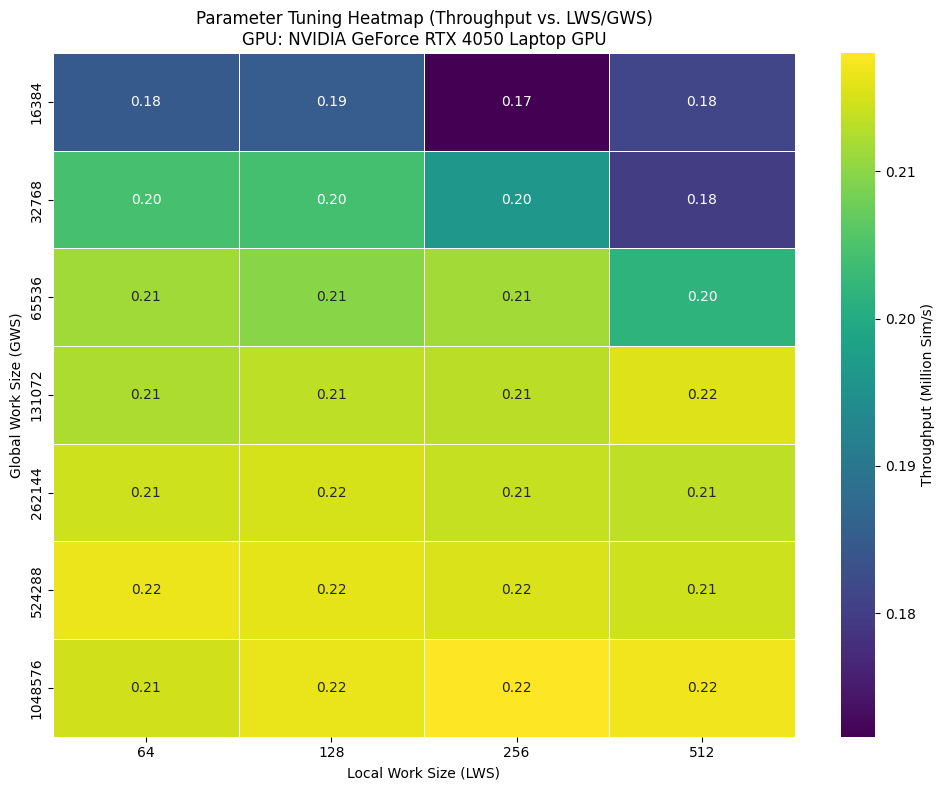

In [12]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Locate the CSV results directory
base_csv_dir = "csv_results"
gpu_dirs = [d for d in os.listdir(base_csv_dir) if os.path.isdir(os.path.join(base_csv_dir, d))]
gpu_folder = gpu_dirs[0] if gpu_dirs else "NVIDIA_GeForce_RTX_4050_Laptop_GPU"
csv_path = os.path.join(base_csv_dir, gpu_folder, "lws_gws_sweep.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    
    # Pivot for Heatmap plotting
    pivot_df = df.pivot(index="GWS", columns="LWS", values="Throughput (Sim/s)")
    # Divide throughput by 1e6 to represent in Millions of simulations per second
    pivot_df = pivot_df / 1e6

    gpu_name = gpu_folder.replace('_', ' ')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        cbar_kws={"label": "Throughput (Million Sim/s)"},
        linewidths=0.5,
    )
    plt.title(f"Parameter Tuning Heatmap (Throughput vs. LWS/GWS)\nGPU: {gpu_name}")
    plt.xlabel("Local Work Size (LWS)")
    plt.ylabel("Global Work Size (GWS)")

    plt.tight_layout()
    plt.show()
else:
    print(f"CSV not found: {csv_path}")


## 3.2 Simulation Scaling

The scaling of the simulation execution time is measured as the number of Monte Carlo runs ($R$) scales from thousands to millions. This analysis is crucial to identify the crossover point where the overhead of OpenCL runtime compilation, device context setup, and memory transfers between the host and the device is offset by the parallel execution throughput of the GPU. Different kernels are compared to evaluate how execution scales with increasing workload size.


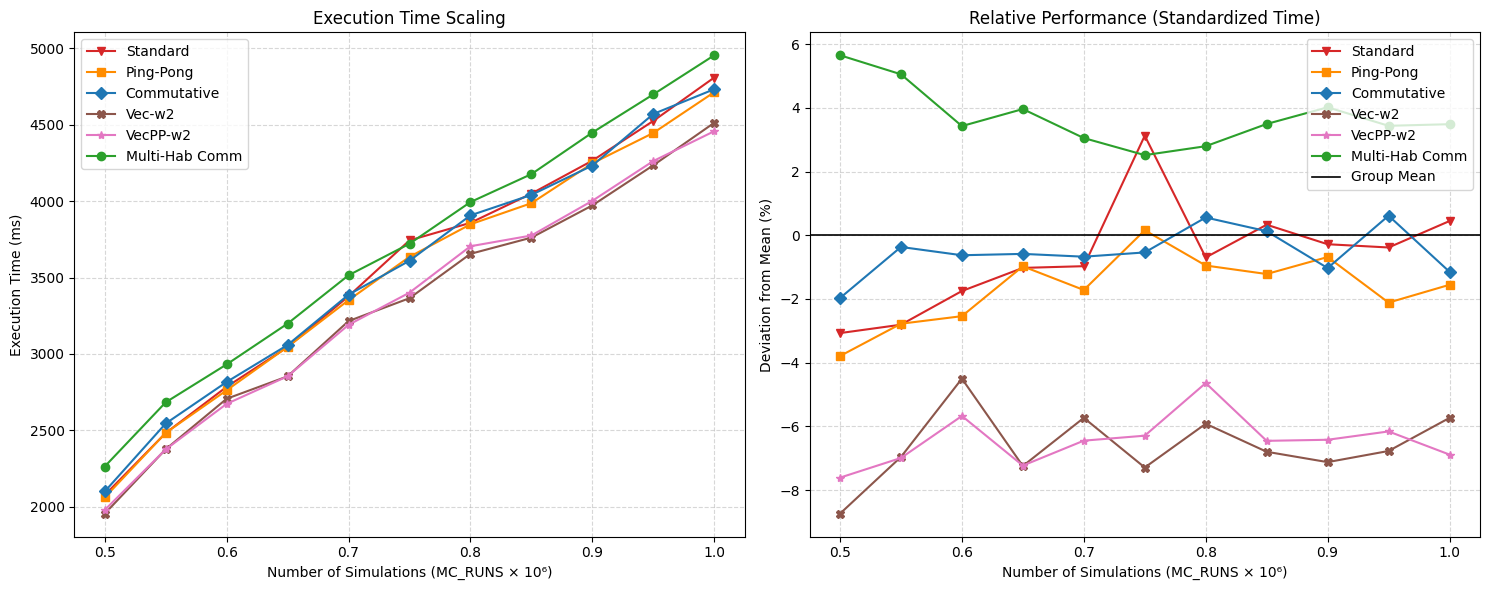

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_csv_dir = "csv_results"
gpu_dirs = [d for d in os.listdir(base_csv_dir) if os.path.isdir(os.path.join(base_csv_dir, d))]
gpu_folder = gpu_dirs[0] if gpu_dirs else "NVIDIA_GeForce_RTX_4050_Laptop_GPU"
csv_path = os.path.join(base_csv_dir, gpu_folder, "simulation_scaling.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Distinct markers and colors for plotting (matching the style of the user's graph)
    style_opts = {
        "Standard": {"color": "tab:red", "marker": "v",
        "Global-Seed": {"color": "tab:purple", "marker": "^"},
        "Multi-Hab GS": {"color": "teal", "marker": "p"},
        "Contiguous": {"color": "olive", "marker": "h"},
        "Multi-Hab Cont": {"color": "navy", "marker": "H"},
    },
        "Ping-Pong": {"color": "darkorange", "marker": "s"},
        "Commutative": {"color": "tab:blue", "marker": "D"},
        "Vec-w2": {"color": "tab:brown", "marker": "X"},
        "VecPP-w2": {"color": "tab:pink", "marker": "*"},
        "Multi-Hab Comm": {"color": "tab:green", "marker": "o"},
    }

    # Plot Subplot 1: Execution Time Scaling
    for name in style_opts.keys():
        sub_df = df[df["Kernel"] == name]
        if not sub_df.empty:
            ax1.plot(
                sub_df["MC_RUNS"] / 1e6,
                sub_df["Time (ms)"],
                label=name,
                color=style_opts[name]["color"],
                marker=style_opts[name]["marker"],
                linewidth=1.5,
            )
    ax1.set_title("Execution Time Scaling")
    ax1.set_xlabel("Number of Simulations (MC_RUNS × 10⁶)")
    ax1.set_ylabel("Execution Time (ms)")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend()

    # Plot Subplot 2: Relative Performance (Standardized Time)
    for name in style_opts.keys():
        sub_df = df[df["Kernel"] == name]
        if not sub_df.empty:
            ax2.plot(
                sub_df["MC_RUNS"] / 1e6,
                sub_df["Deviation (%)"],
                label=name,
                color=style_opts[name]["color"],
                marker=style_opts[name]["marker"],
                linewidth=1.5,
            )
    ax2.axhline(0, color="black", linestyle="-", linewidth=1.2, label="Group Mean")
    ax2.set_title("Relative Performance (Standardized Time)")
    ax2.set_xlabel("Number of Simulations (MC_RUNS × 10⁶)")
    ax2.set_ylabel("Deviation from Mean (%)")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print(f"CSV not found: {csv_path}")


## 3.3 Habitat Size Scaling

The performance is evaluated as the number of active cells ($N_c$) in the habitat increases. Because each work-item in the baseline kernels loops over all active cells sequentially, increasing $N_c$ scales the work-item workload. Vectorized kernels are compared against scalar kernels to evaluate the effects of wide SIMD operations and vector register usage on the GPU's memory cache efficiency and register allocation limits.


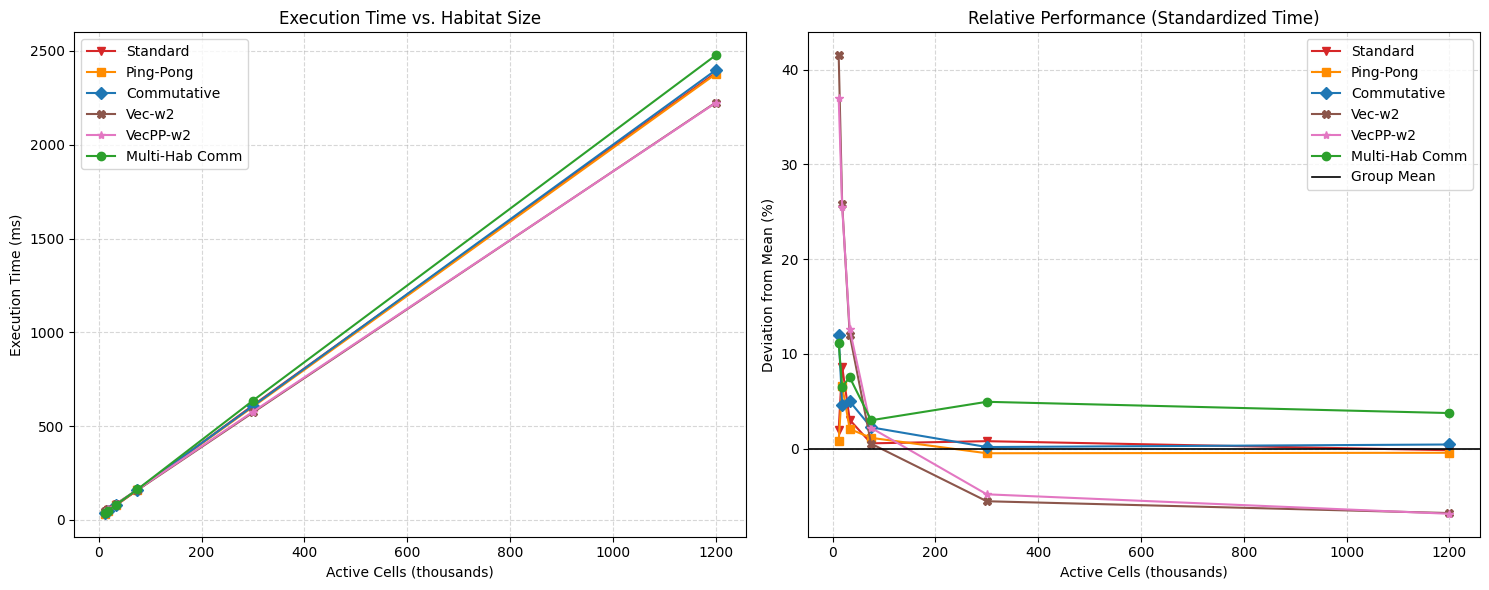

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_csv_dir = "csv_results"
gpu_dirs = [d for d in os.listdir(base_csv_dir) if os.path.isdir(os.path.join(base_csv_dir, d))]
gpu_folder = gpu_dirs[0] if gpu_dirs else "NVIDIA_GeForce_RTX_4050_Laptop_GPU"
csv_path = os.path.join(base_csv_dir, gpu_folder, "size_scaling.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Distinct markers and colors for plotting (matching the style)
    style_opts = {
        "Standard": {"color": "tab:red", "marker": "v",
        "Global-Seed": {"color": "tab:purple", "marker": "^"},
        "Multi-Hab GS": {"color": "teal", "marker": "p"},
        "Contiguous": {"color": "olive", "marker": "h"},
        "Multi-Hab Cont": {"color": "navy", "marker": "H"},
    },
        "Ping-Pong": {"color": "darkorange", "marker": "s"},
        "Commutative": {"color": "tab:blue", "marker": "D"},
        "Vec-w2": {"color": "tab:brown", "marker": "X"},
        "VecPP-w2": {"color": "tab:pink", "marker": "*"},
        "Multi-Hab Comm": {"color": "tab:green", "marker": "o"},
    }

    # Plot Subplot 1: Execution Time Scaling
    for name in style_opts.keys():
        sub_df = df[df["Kernel"] == name]
        if not sub_df.empty:
            ax1.plot(
                sub_df["Active_Cells"] / 1000.0,
                sub_df["Time (ms)"],
                label=name,
                color=style_opts[name]["color"],
                marker=style_opts[name]["marker"],
                linewidth=1.5,
            )
    ax1.set_title("Execution Time vs. Habitat Size")
    ax1.set_xlabel("Active Cells (thousands)")
    ax1.set_ylabel("Execution Time (ms)")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend()

    # Plot Subplot 2: Relative Performance (Standardized Time)
    for name in style_opts.keys():
        sub_df = df[df["Kernel"] == name]
        if not sub_df.empty:
            ax2.plot(
                sub_df["Active_Cells"] / 1000.0,
                sub_df["Deviation (%)"],
                label=name,
                color=style_opts[name]["color"],
                marker=style_opts[name]["marker"],
                linewidth=1.5,
            )
    ax2.axhline(0, color="black", linestyle="-", linewidth=1.2, label="Group Mean")
    ax2.set_title("Relative Performance (Standardized Time)")
    ax2.set_xlabel("Active Cells (thousands)")
    ax2.set_ylabel("Deviation from Mean (%)")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print(f"CSV not found: {csv_path}")


## 3.4 Multi-Habitat Scaling

The performance impact of simulating multiple overlapping habitats concurrently is evaluated. The Habitat-Centric approach, which loops over each habitat sequentially, is compared with the Map-Centric approach, which uses a bitmask encoding of habitat presence. The Map-Centric implementation is designed to optimize memory bandwidth and reduce redundant pseudo-random number generator (PRNG) updates by performing a single NDRange sweep over the spatial grid.


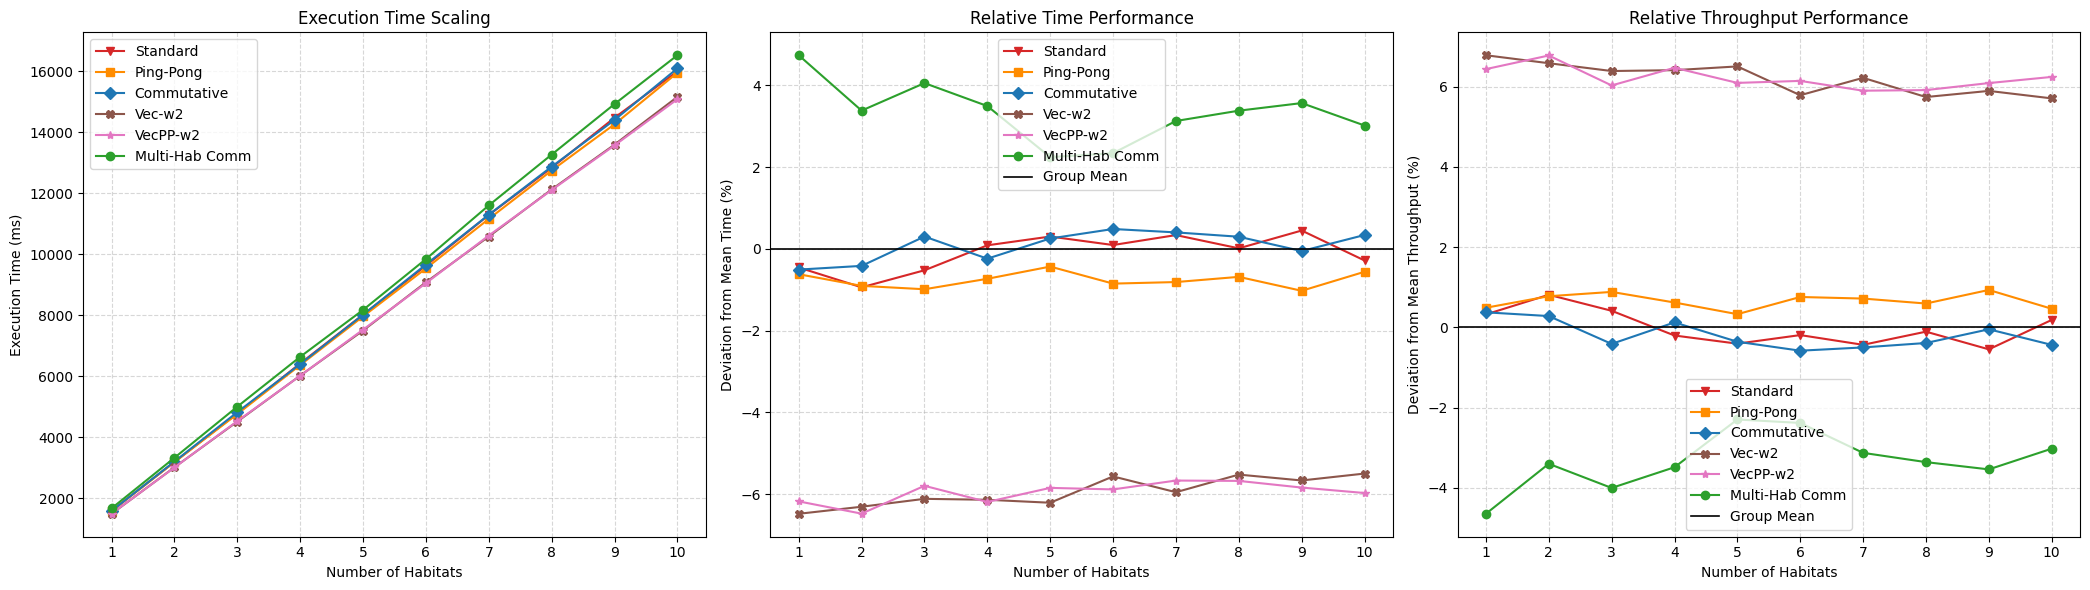

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_csv_dir = "csv_results"
gpu_dirs = [d for d in os.listdir(base_csv_dir) if os.path.isdir(os.path.join(base_csv_dir, d))]
gpu_folder = gpu_dirs[0] if gpu_dirs else "NVIDIA_GeForce_RTX_4050_Laptop_GPU"
csv_path = os.path.join(base_csv_dir, gpu_folder, "habitat_scaling.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    
    # 6. Plotting (3 subplots)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))

    style_opts = {
        "Standard": {"color": "tab:red", "marker": "v",
        "Global-Seed": {"color": "tab:purple", "marker": "^"},
        "Multi-Hab GS": {"color": "teal", "marker": "p"},
        "Contiguous": {"color": "olive", "marker": "h"},
        "Multi-Hab Cont": {"color": "navy", "marker": "H"},
    },
        "Ping-Pong": {"color": "darkorange", "marker": "s"},
        "Commutative": {"color": "tab:blue", "marker": "D"},
        "Vec-w2": {"color": "tab:brown", "marker": "X"},
        "VecPP-w2": {"color": "tab:pink", "marker": "*"},
        "Multi-Hab Comm": {"color": "tab:green", "marker": "o"},
    }

    n_habitats_total = df["N_HABITATS"].max()

    # Plot Subplot 1: Absolute Time
    for name in style_opts.keys():
        sub_df = df[df["Kernel"] == name]
        if not sub_df.empty:
            ax1.plot(
                sub_df["N_HABITATS"],
                sub_df["Time (ms)"],
                label=name,
                color=style_opts[name]["color"],
                marker=style_opts[name]["marker"],
                linewidth=1.5,
            )
    ax1.set_title("Execution Time Scaling")
    ax1.set_xlabel("Number of Habitats")
    ax1.set_ylabel("Execution Time (ms)")
    ax1.set_xticks(range(1, n_habitats_total + 1))
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend()

    # Plot Subplot 2: Relative Performance (Standardized Time)
    for name in style_opts.keys():
        sub_df = df[df["Kernel"] == name]
        if not sub_df.empty:
            ax2.plot(
                sub_df["N_HABITATS"],
                sub_df["Deviation Time (%)"],
                label=name,
                color=style_opts[name]["color"],
                marker=style_opts[name]["marker"],
                linewidth=1.5,
            )
    ax2.axhline(0, color="black", linestyle="-", linewidth=1.2, label="Group Mean")
    ax2.set_title("Relative Time Performance")
    ax2.set_xlabel("Number of Habitats")
    ax2.set_ylabel("Deviation from Mean Time (%)")
    ax2.set_xticks(range(1, n_habitats_total + 1))
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend()

    # Plot Subplot 3: Relative Throughput
    for name in style_opts.keys():
        sub_df = df[df["Kernel"] == name]
        if not sub_df.empty:
            ax3.plot(
                sub_df["N_HABITATS"],
                sub_df["Deviation Throughput (%)"],
                label=name,
                color=style_opts[name]["color"],
                marker=style_opts[name]["marker"],
                linewidth=1.5,
            )
    ax3.axhline(0, color="black", linestyle="-", linewidth=1.2, label="Group Mean")
    ax3.set_title("Relative Throughput Performance")
    ax3.set_xlabel("Number of Habitats")
    ax3.set_ylabel("Deviation from Mean Throughput (%)")
    ax3.set_xticks(range(1, n_habitats_total + 1))
    ax3.grid(True, linestyle="--", alpha=0.5)
    ax3.legend()

    plt.tight_layout()
    plt.show()
else:
    print(f"CSV not found: {csv_path}")


## 3.5 Preprocessing and Compaction

The execution times of different stream compaction algorithms are compared. Prior to the simulation, sparse maps are compacted into dense 1D arrays to prevent work-item divergence. Host-side NumPy compaction variants are compared with GPU-based parallel prefix scan operations (using the Hillis-Steele algorithm in local work-group memory). This benchmark evaluates the overhead of the preprocessing step relative to the total execution time.


/tmp/ipykernel_24841/3995729741.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df["Variant"], rotation=30, ha="right")
/tmp/ipykernel_24841/3995729741.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(df["Variant"], rotation=30, ha="right")


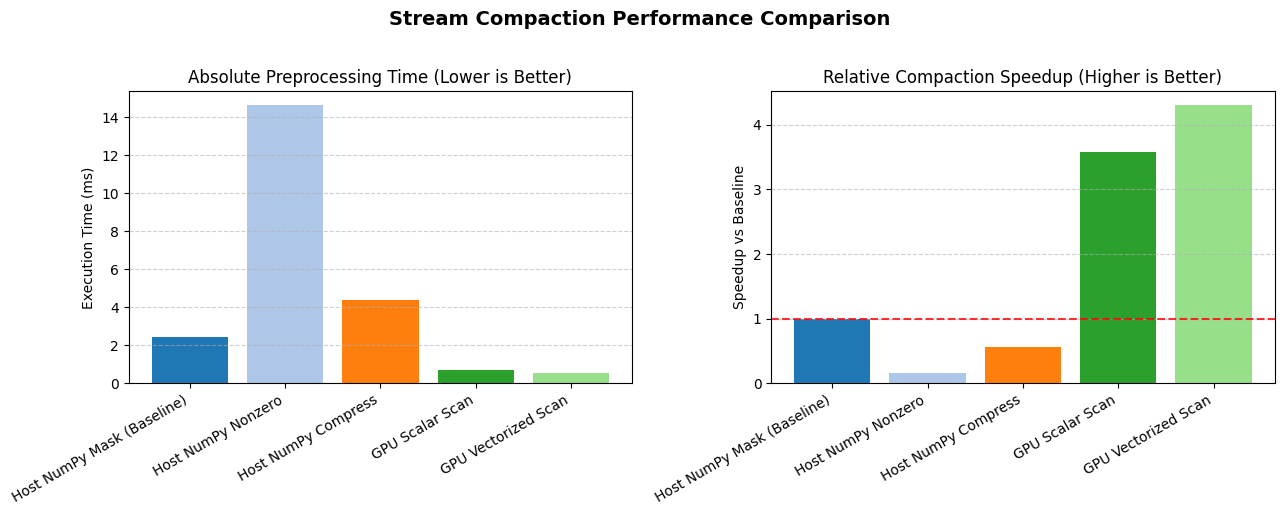

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_csv_dir = "csv_results"
gpu_dirs = [d for d in os.listdir(base_csv_dir) if os.path.isdir(os.path.join(base_csv_dir, d))]
gpu_folder = gpu_dirs[0] if gpu_dirs else "NVIDIA_GeForce_RTX_4050_Laptop_GPU"
csv_path = os.path.join(base_csv_dir, gpu_folder, "compaction_benchmark.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    colors = ["#1f77b4", "#aec7e8", "#ff7f0e", "#2ca02c", "#98df8a"]

    ax1.bar(df["Variant"], df["Time (ms)"], color=colors[:len(df)])
    ax1.set_ylabel("Execution Time (ms)")
    ax1.set_title("Absolute Preprocessing Time (Lower is Better)")
    ax1.set_xticklabels(df["Variant"], rotation=30, ha="right")
    ax1.grid(axis="y", linestyle="--", alpha=0.6)

    ax2.bar(df["Variant"], df["Relative Speedup"], color=colors[:len(df)])
    ax2.set_ylabel("Speedup vs Baseline")
    ax2.set_title("Relative Compaction Speedup (Higher is Better)")
    ax2.set_xticklabels(df["Variant"], rotation=30, ha="right")
    ax2.axhline(1.0, color="red", linestyle="--", alpha=0.8, label="Baseline")
    ax2.grid(axis="y", linestyle="--", alpha=0.6)

    plt.suptitle("Stream Compaction Performance Comparison", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"CSV not found: {csv_path}")


## 3.6 Random Number Generator Overhead

To isolate the computational cost of the pseudo-random number generator (PRNG) MWC64X, the execution times of the kernels are compared under two modes: a standard simulation mode ('With RNG') and a mode where the PRNG operations are bypassed ('Without RNG'). This comparison reveals the fraction of execution cycles dedicated strictly to mathematical operations of the generator compared to memory operations and reduction operations.


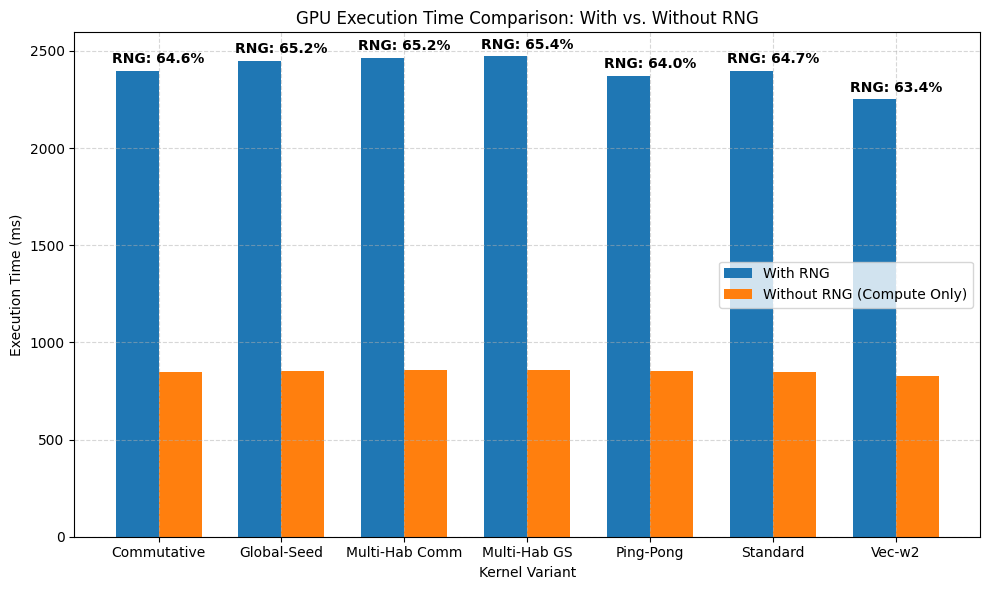

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_csv_dir = "csv_results"
gpu_dirs = [d for d in os.listdir(base_csv_dir) if os.path.isdir(os.path.join(base_csv_dir, d))]
gpu_folder = gpu_dirs[0] if gpu_dirs else "NVIDIA_GeForce_RTX_4050_Laptop_GPU"
csv_path = os.path.join(base_csv_dir, gpu_folder, "rng_vs_norng.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df_pivot = df.pivot(index="Kernel", columns="Mode", values="Time (ms)")
    df_pivot["RNG Overhead (ms)"] = df_pivot["With RNG"] - df_pivot["Without RNG"]
    df_pivot["RNG Cost (%)"] = (df_pivot["RNG Overhead (ms)"] / df_pivot["With RNG"]) * 100
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    kernels = df_pivot.index
    x = np.arange(len(kernels))
    width = 0.35

    ax.bar(x - width/2, df_pivot["With RNG"], width, label="With RNG", color="tab:blue")
    ax.bar(x + width/2, df_pivot["Without RNG"], width, label="Without RNG (Compute Only)", color="tab:orange")

    # Add text labels for RNG cost on top of the bars
    for idx, (k, row) in enumerate(df_pivot.iterrows()):
        overhead_pct = row["RNG Cost (%)"]
        ax.text(
            idx,
            row["With RNG"] + (row["With RNG"] * 0.01),
            f"RNG: {overhead_pct:.1f}%",
            ha="center",
            va="bottom",
            fontweight="bold",
            color="black"
        )

    ax.set_title("GPU Execution Time Comparison: With vs. Without RNG")
    ax.set_xlabel("Kernel Variant")
    ax.set_ylabel("Execution Time (ms)")
    ax.set_xticks(x)
    ax.set_xticklabels(kernels)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()
else:
    print(f"CSV not found: {csv_path}")

## 3.7 2D Topology Aspect Ratio Sweep

The 2D kernels map the problem onto a 2-dimensional `(run_lanes, cell_lanes)` grid. The overall performance is heavily influenced by how the Local Work Size (LWS) is partitioned between the two axes.

This benchmark evaluates the `Standard 1D (Baseline)` against the `2D` and `2D Transposed` kernels across various aspect ratios, starting from purely 1D along the cells (`256x1`) to purely 1D along the runs (`1x256`).


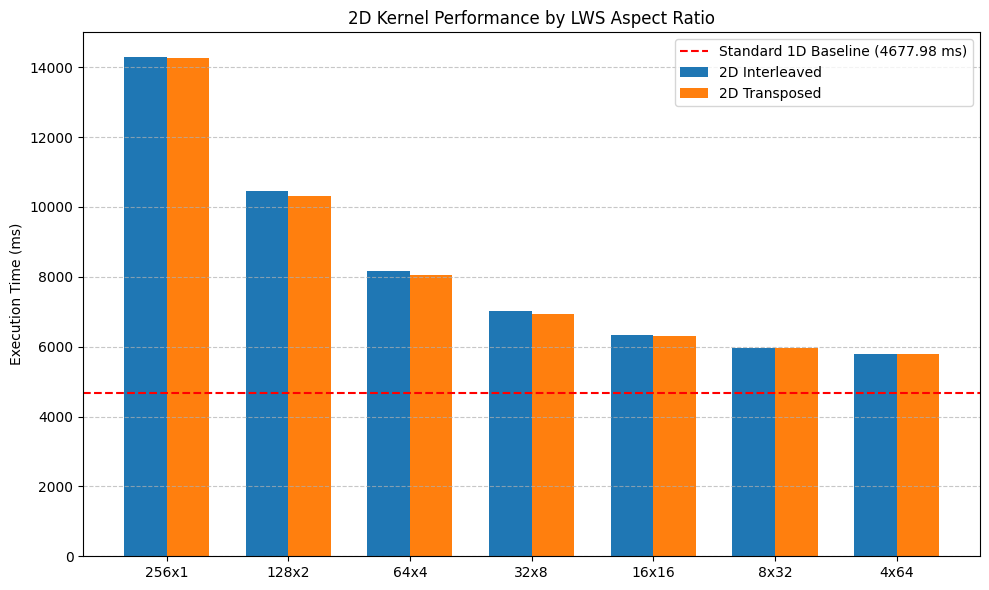

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

base_csv_dir = "csv_results"
gpu_dirs = [d for d in os.listdir(base_csv_dir) if os.path.isdir(os.path.join(base_csv_dir, d))]
gpu_folder = gpu_dirs[0] if gpu_dirs else "unknown_gpu"
csv_path = os.path.join(base_csv_dir, gpu_folder, "benchmark_2d_topology.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    
    baseline_df = df[df["Kernel"] == "Standard 1D (Baseline)"]
    if not baseline_df.empty:
        baseline_time = baseline_df["Time (ms)"].values[0]
    else:
        baseline_time = 0.0
    
    aspects = df["Aspect Ratio"].dropna().unique().tolist()
    
    df_2d = df[df["Kernel"] == "2D Interleaved"]
    df_2dt = df[df["Kernel"] == "2D Transposed"]
    
    y_2d = []
    y_2dt = []
    
    for aspect in aspects:
        match_2d = df_2d[df_2d["Aspect Ratio"] == aspect]
        y_2d.append(match_2d["Time (ms)"].values[0] if not match_2d.empty else 0.0)
        
        match_2dt = df_2dt[df_2dt["Aspect Ratio"] == aspect]
        y_2dt.append(match_2dt["Time (ms)"].values[0] if not match_2dt.empty else 0.0)
    
    x = np.arange(len(aspects))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, y_2d, width, label='2D Interleaved')
    rects2 = ax.bar(x + width/2, y_2dt, width, label='2D Transposed')
    
    if baseline_time > 0:
        ax.axhline(baseline_time, color='r', linestyle='--', label=f'Standard 1D Baseline ({baseline_time:.2f} ms)')
    
    ax.set_ylabel('Execution Time (ms)')
    ax.set_title('2D Kernel Performance by LWS Aspect Ratio')
    ax.set_xticks(x)
    ax.set_xticklabels(aspects)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"CSV not found: {csv_path}")

## 3.8 Map-Centric vs Run-Centric Scaling

The `Map-Centric` architecture parallelizes over the spatial dimension (the map cells) instead of the simulations. It updates 64 runs at once via bitwise logic within a single work-item mapped to a spatial cell.

Since its grid size is tied to $N_c$ (number of active cells) rather than $R$ (number of runs), its performance scales entirely differently. This benchmark evaluates the execution time crossover point between the baseline run-centric method and the map-centric method as the map size grows exponentially.


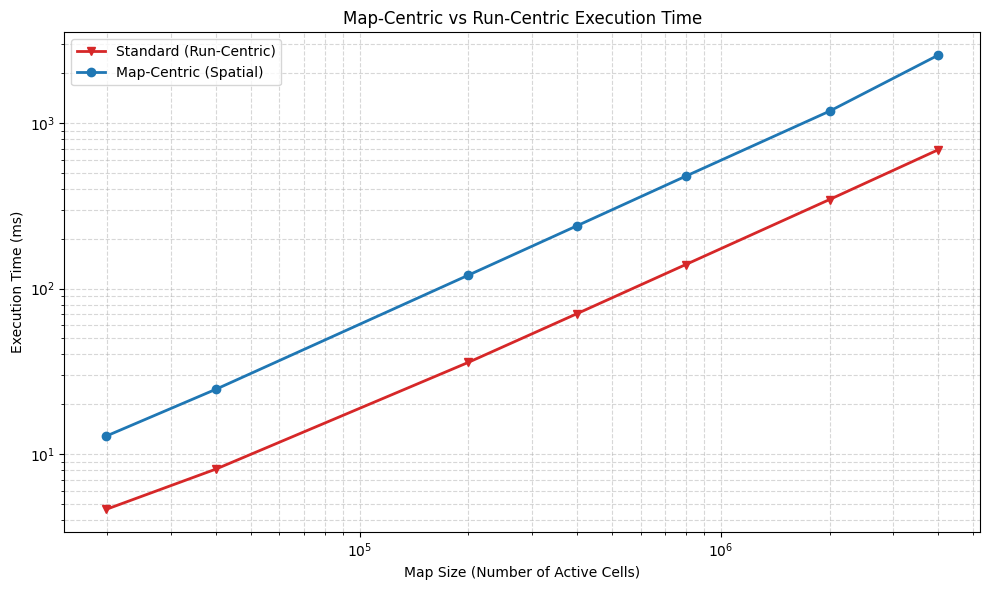

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_csv_dir = "csv_results"
gpu_dirs = [d for d in os.listdir(base_csv_dir) if os.path.isdir(os.path.join(base_csv_dir, d))]
gpu_folder = gpu_dirs[0] if gpu_dirs else "unknown_gpu"
csv_path = os.path.join(base_csv_dir, gpu_folder, "benchmark_map_centric.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))

    style_opts_mc = {
        "Standard (Run-Centric)": {"color": "tab:red", "marker": "v", "linestyle": "-"},
        "Map-Centric (Spatial)": {"color": "tab:blue", "marker": "o", "linestyle": "-"},
    }

    for name in style_opts_mc.keys():
        sub_df = df[df["Kernel"] == name]
        if not sub_df.empty:
            ax1.plot(
                sub_df["N_Cells"],
                sub_df["Time (ms)"],
                label=name,
                color=style_opts_mc[name]["color"],
                marker=style_opts_mc[name]["marker"],
                linestyle=style_opts_mc[name]["linestyle"],
                linewidth=2,
            )

    ax1.set_title("Map-Centric vs Run-Centric Execution Time")
    ax1.set_xlabel("Map Size (Number of Active Cells)")
    ax1.set_ylabel("Execution Time (ms)")
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.grid(True, which="both", linestyle="--", alpha=0.5)
    ax1.legend()

    plt.tight_layout()
    plt.show()
else:
    print(f"CSV not found: {csv_path}")

# 4. Cross-Hardware Benchmark

This section synthesises all individual benchmark results into a set of single comparable scores for the three GPUs evaluated in this study:

| Label | GPU |
|---|---|
| **RTX 3050** | NVIDIA GeForce RTX 3050 |
| **RTX 4050 Laptop** | NVIDIA GeForce RTX 4050 Laptop GPU |
| **RTX 4090** | NVIDIA GeForce RTX 4090 |

Only Monte Carlo (MC) kernels are considered. All kernels present in each sweep are included in the aggregate score.

## 4.1 Scoring Methodology

Three scoring formulas are applied, one per benchmark category:

### A — Scaling Sweeps (`simulation_scaling`, `habitat_scaling`, `size_scaling`)
**Score = Geometric Mean of Throughput (M-Sim/s)** across all sweep points and all kernels.

$$\text{Score}_A = \left(\prod_{i=1}^{n} T_i\right)^{1/n}$$

where $T_i$ is the throughput (Simulations/s) of the $i$-th measurement point. The geometric mean weights relative ratios rather than absolute values, preventing extreme low-load throughput from dominating the aggregate — the same principle used in SPEC CPU and Geekbench.

### B — LWS/GWS Sweep (`lws_gws_sweep`)
**Score = Peak Throughput (M-Sim/s)** — the single best configuration observed.

$$\text{Score}_B = \max_i(T_i)$$

### C — RNG Efficiency (`rng_vs_norng`)
**Score = RNG Efficiency Factor (%)** — mean ratio of throughput *with* vs *without* RNG across all kernels.

$$\text{Score}_C = \frac{1}{K}\sum_{k=1}^{K} \frac{T_k^{\text{RNG}}}{T_k^{\text{no-RNG}}} \times 100$$

A value closer to 100 % indicates that the PRNG overhead is minimal for that architecture.

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import gmean

BASE_CSV = "csv_results"

GPU_MAP = {
    "RTX 3050":        "NVIDIA_GeForce_RTX_3050",
    "RTX 4050 Laptop": "NVIDIA_GeForce_RTX_4050_Laptop_GPU",
    "RTX 4090":        "NVIDIA_GeForce_RTX_4090",
}

GPU_COLORS = {
    "RTX 3050":        "#66BB6A",
    "RTX 4050 Laptop": "#42A5F5",
    "RTX 4090":        "#FF7043",
}

GPU_LABELS = list(GPU_MAP.keys())

# Shared plot style
plt.rcParams.update({
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor":   "#16213e",
    "axes.edgecolor":   "#334",
    "axes.labelcolor":  "#cdd6f4",
    "xtick.color":      "#cdd6f4",
    "ytick.color":      "#cdd6f4",
    "text.color":       "#cdd6f4",
    "grid.color":       "#2a2a4a",
    "grid.linestyle":   "--",
    "legend.facecolor": "#1a1a2e",
    "legend.edgecolor": "#334",
})

def bar_chart(scores: dict, title: str, ylabel: str, ax=None):
    """Render a dark-themed bar chart for a single score dict."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4), facecolor="#1a1a2e")
    labels = list(scores.keys())
    values = list(scores.values())
    colors = [GPU_COLORS[l] for l in labels]
    bars = ax.bar(labels, values, color=colors, width=0.5, zorder=3, edgecolor="#0d0d1a", linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold",
                color=bar.get_facecolor())
    return ax

print("Setup complete.")

Setup complete.


## 4.2 Simulation Scaling Score

Geometric mean of throughput across all `(MC_RUNS, Kernel)` rows in `simulation_scaling.csv`.
Throughput is computed as `MC_RUNS / (Time_ms / 1000)` since the CSV stores raw execution time.

  [RTX 3050] Simulation Scaling Score = 0.1443 M-Sim/s
  [RTX 4050 Laptop] Simulation Scaling Score = 0.2185 M-Sim/s
  [RTX 4090] Simulation Scaling Score = 1.4261 M-Sim/s


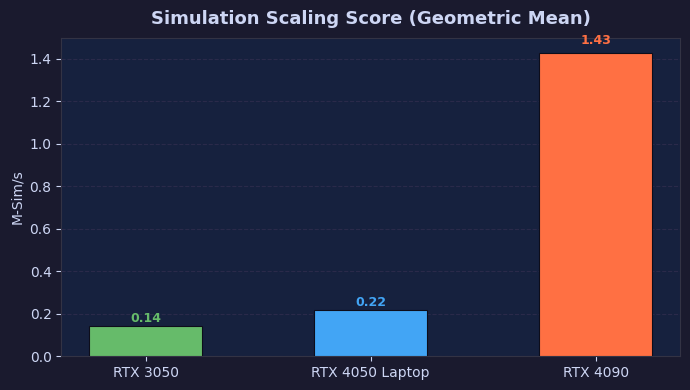

In [21]:
sim_scores = {}
for label, folder in GPU_MAP.items():
    path = os.path.join(BASE_CSV, folder, "simulation_scaling.csv")
    if not os.path.exists(path):
        print(f"  [{label}] simulation_scaling.csv not found — skipping")
        continue
    df = pd.read_csv(path)
    df["Throughput"] = df["MC_RUNS"] / (df["Time (ms)"] / 1000)  # Sim/s
    score = gmean(df["Throughput"].values) / 1e6  # M-Sim/s
    sim_scores[label] = score
    print(f"  [{label}] Simulation Scaling Score = {score:.4f} M-Sim/s")

fig, ax = plt.subplots(figsize=(7, 4), facecolor="#1a1a2e")
bar_chart(sim_scores, "Simulation Scaling Score (Geometric Mean)", "M-Sim/s", ax=ax)
plt.tight_layout()
plt.show()

## 4.3 Habitat Scaling Score

Geometric mean of throughput across all `(N_HABITATS, Kernel)` rows in `habitat_scaling.csv`.
The `Throughput (Sim/s)` column is already precomputed in the CSV.

  [RTX 3050] Habitat Scaling Score = 0.2152 M-Sim/s
  [RTX 4050 Laptop] Habitat Scaling Score = 0.3103 M-Sim/s
  [RTX 4090] Habitat Scaling Score = 2.1879 M-Sim/s


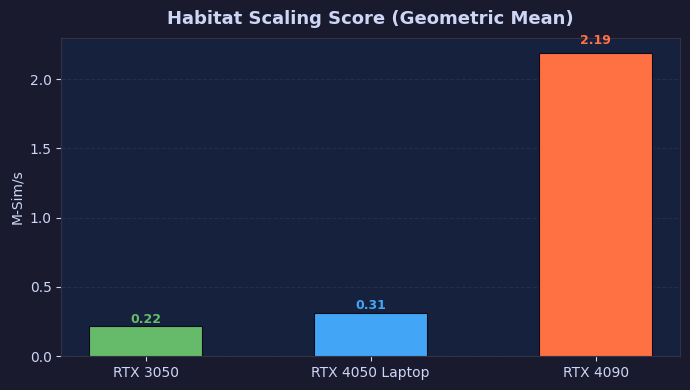

In [22]:
hab_scores = {}
for label, folder in GPU_MAP.items():
    path = os.path.join(BASE_CSV, folder, "habitat_scaling.csv")
    if not os.path.exists(path):
        print(f"  [{label}] habitat_scaling.csv not found — skipping")
        continue
    df = pd.read_csv(path)
    score = gmean(df["Throughput (Sim/s)"].values) / 1e6  # M-Sim/s
    hab_scores[label] = score
    print(f"  [{label}] Habitat Scaling Score = {score:.4f} M-Sim/s")

fig, ax = plt.subplots(figsize=(7, 4), facecolor="#1a1a2e")
bar_chart(hab_scores, "Habitat Scaling Score (Geometric Mean)", "M-Sim/s", ax=ax)
plt.tight_layout()
plt.show()

## 4.4 Size Scaling Score

Geometric mean of throughput across all `(Factor, Kernel)` rows in `size_scaling.csv`.
`N_MC_RUNS = 500 000` is hardcoded in [`benchmark/benchmark_size_scaling.py`](benchmark/benchmark_size_scaling.py) (line 82),
so throughput is computed as `500_000 / (Time_ms / 1000)`.

  [RTX 3050] Size Scaling Score = 2.0102 M-Sim/s
  [RTX 4050 Laptop] Size Scaling Score = 2.9544 M-Sim/s
  [RTX 4090] Size Scaling Score = 20.2869 M-Sim/s


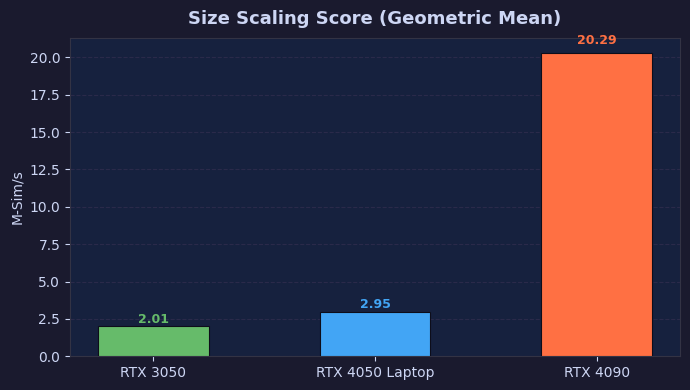

In [23]:
MC_RUNS_SIZE = 500_000  # from benchmark/benchmark_size_scaling.py, line 82

size_scores = {}
for label, folder in GPU_MAP.items():
    path = os.path.join(BASE_CSV, folder, "size_scaling.csv")
    if not os.path.exists(path):
        print(f"  [{label}] size_scaling.csv not found — skipping")
        continue
    df = pd.read_csv(path)
    df["Throughput"] = MC_RUNS_SIZE / (df["Time (ms)"] / 1000)  # Sim/s
    score = gmean(df["Throughput"].values) / 1e6  # M-Sim/s
    size_scores[label] = score
    print(f"  [{label}] Size Scaling Score = {score:.4f} M-Sim/s")

fig, ax = plt.subplots(figsize=(7, 4), facecolor="#1a1a2e")
bar_chart(size_scores, "Size Scaling Score (Geometric Mean)", "M-Sim/s", ax=ax)
plt.tight_layout()
plt.show()

## 4.5 LWS/GWS Peak Throughput

Peak throughput from `lws_gws_sweep.csv`: the single best `(LWS, GWS)` configuration.
The `Throughput (Sim/s)` column is already precomputed in the CSV.

  [RTX 3050] Peak Throughput = 0.1543 M-Sim/s  (LWS=512, GWS=1048576)
  [RTX 4050 Laptop] Peak Throughput = 0.2239 M-Sim/s  (LWS=64, GWS=524288)
  [RTX 4090] Peak Throughput = 1.6088 M-Sim/s  (LWS=256, GWS=1048576)


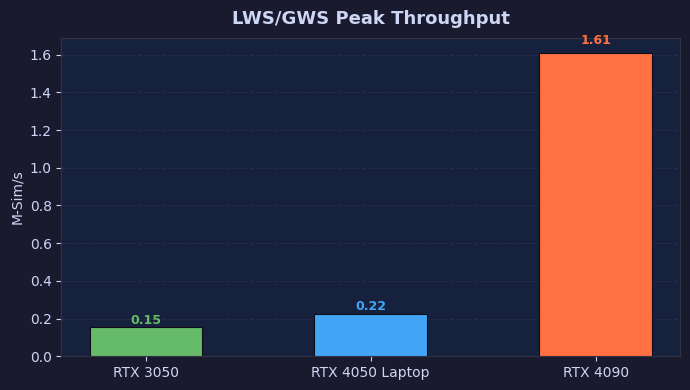

In [24]:
lws_scores = {}
for label, folder in GPU_MAP.items():
    path = os.path.join(BASE_CSV, folder, "lws_gws_sweep.csv")
    if not os.path.exists(path):
        print(f"  [{label}] lws_gws_sweep.csv not found — skipping")
        continue
    df = pd.read_csv(path)
    score = df["Throughput (Sim/s)"].max() / 1e6  # M-Sim/s
    lws_scores[label] = score
    best_row = df.loc[df["Throughput (Sim/s)"].idxmax()]
    print(f"  [{label}] Peak Throughput = {score:.4f} M-Sim/s  "
          f"(LWS={int(best_row['LWS'])}, GWS={int(best_row['GWS'])})")

fig, ax = plt.subplots(figsize=(7, 4), facecolor="#1a1a2e")
bar_chart(lws_scores, "LWS/GWS Peak Throughput", "M-Sim/s", ax=ax)
plt.tight_layout()
plt.show()

## 4.6 RNG Efficiency Factor

Mean ratio of throughput *with* vs *without* RNG across all kernel variants in `rng_vs_norng.csv`.
100 % would mean zero overhead from the PRNG.

  [RTX 3050] RNG Efficiency = 36.27%
  [RTX 4050 Laptop] RNG Efficiency = 35.53%
  [RTX 4090] RNG Efficiency = 37.11%


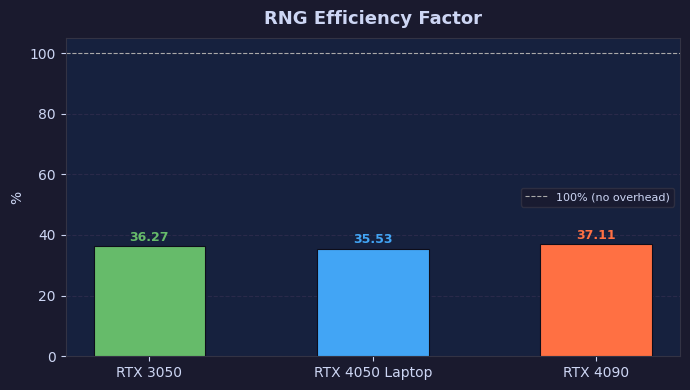

In [25]:
rng_scores = {}
for label, folder in GPU_MAP.items():
    path = os.path.join(BASE_CSV, folder, "rng_vs_norng.csv")
    if not os.path.exists(path):
        print(f"  [{label}] rng_vs_norng.csv not found — skipping")
        continue
    df = pd.read_csv(path)
    with_rng    = df[df["Mode"] == "With RNG"].set_index("Kernel")["Throughput (Sim/s)"]
    without_rng = df[df["Mode"] == "Without RNG"].set_index("Kernel")["Throughput (Sim/s)"]
    common = with_rng.index.intersection(without_rng.index)
    eff = (with_rng[common] / without_rng[common] * 100).mean()
    rng_scores[label] = eff
    print(f"  [{label}] RNG Efficiency = {eff:.2f}%")

fig, ax = plt.subplots(figsize=(7, 4), facecolor="#1a1a2e")
bar_chart(rng_scores, "RNG Efficiency Factor", "%", ax=ax)
ax.set_ylim(0, 105)
ax.axhline(100, color="#aaaaaa", linewidth=0.8, linestyle="--", label="100% (no overhead)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4.7 Summary — Cross-Hardware Comparison

All five scores are collected, normalised to `[0, 1]` (best GPU in each category = 1.0),
and displayed as a grouped bar chart and a radar (spider) chart for direct visual comparison.

Raw scores:
                 Sim Scaling\n(M-Sim/s)  Habitat Scaling\n(M-Sim/s)  Size Scaling\n(M-Sim/s)  LWS Peak\n(M-Sim/s)  RNG Efficiency\n(%)
RTX 3050                         0.1443                      0.2152                   2.0102               0.1543              36.2707
RTX 4050 Laptop                  0.2185                      0.3103                   2.9544               0.2239              35.5346
RTX 4090                         1.4261                      2.1879                  20.2869               1.6088              37.1083

Normalised scores (best GPU per category = 1.0):
                 Sim Scaling\n(M-Sim/s)  Habitat Scaling\n(M-Sim/s)  Size Scaling\n(M-Sim/s)  LWS Peak\n(M-Sim/s)  RNG Efficiency\n(%)
RTX 3050                         0.1012                      0.0984                   0.0991               0.0959               0.9774
RTX 4050 Laptop                  0.1532                      0.1418                   0.1456               0.1392               

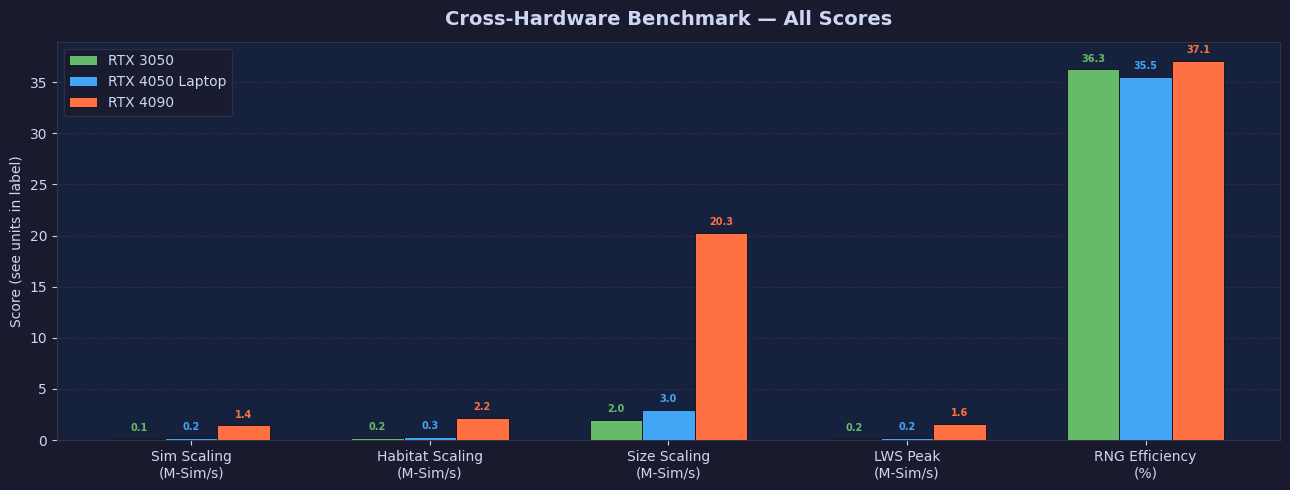

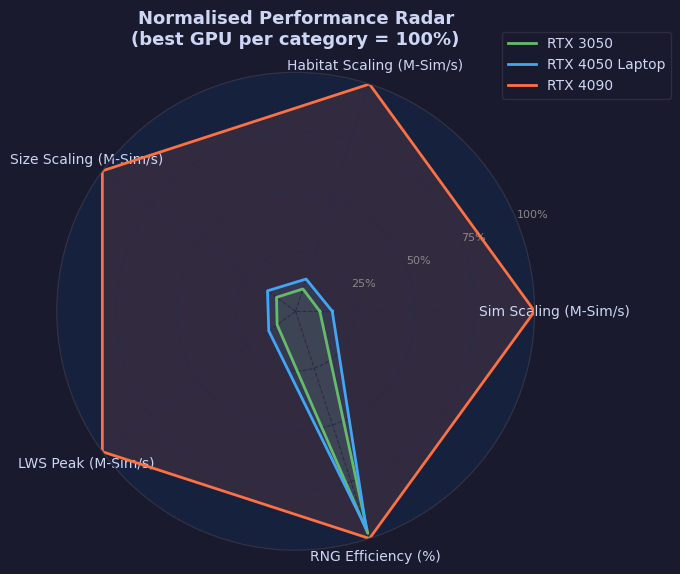


CROSS-HARDWARE BENCHMARK SUMMARY TABLE
GPU                 Sim Scaling (M-Sim/s)Habitat Scaling (M-Sim/s)Size Scaling (M-Sim/s)LWS Peak (M-Sim/s)RNG Efficiency (%)
----------------------------------------------------------------------------------------------------------------------------
RTX 3050                         0.144             0.215             2.010             0.154            36.271
  (normalised)                  10.1%              9.8%              9.9%              9.6%             97.7% 

RTX 4050 Laptop                  0.218             0.310             2.954             0.224            35.535
  (normalised)                  15.3%             14.2%             14.6%             13.9%             95.8% 

RTX 4090                         1.426             2.188            20.287             1.609            37.108
  (normalised)                 100.0%            100.0%            100.0%            100.0%            100.0% 



In [26]:
# ── Collect all scores ─────────────────────────────────────────────────────
all_scores = {
    "Sim Scaling\n(M-Sim/s)":     sim_scores,
    "Habitat Scaling\n(M-Sim/s)": hab_scores,
    "Size Scaling\n(M-Sim/s)":    size_scores,
    "LWS Peak\n(M-Sim/s)":        lws_scores,
    "RNG Efficiency\n(%)":        rng_scores,
}
score_labels = list(all_scores.keys())

# Build a DataFrame with raw values
df_raw = pd.DataFrame({cat: scores for cat, scores in all_scores.items()}, index=GPU_LABELS)

# Normalise per-column (best = 1.0)
df_norm = df_raw.div(df_raw.max(axis=0), axis=1)

print("Raw scores:")
print(df_raw.round(4).to_string())
print("\nNormalised scores (best GPU per category = 1.0):")
print(df_norm.round(4).to_string())

# ── Figure 1: Grouped bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5), facecolor="#1a1a2e")
ax.set_facecolor("#16213e")

n_cats = len(score_labels)
n_gpus = len(GPU_LABELS)
x = np.arange(n_cats)
width = 0.22
offsets = np.linspace(-(n_gpus - 1) / 2, (n_gpus - 1) / 2, n_gpus) * width

for i, gpu in enumerate(GPU_LABELS):
    vals = [all_scores[cat].get(gpu, 0) for cat in score_labels]
    bars = ax.bar(x + offsets[i], vals, width=width, label=gpu,
                  color=GPU_COLORS[gpu], zorder=3, edgecolor="#0d0d1a", linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.015,
                f"{val:.1f}", ha="center", va="bottom",
                fontsize=7, color=GPU_COLORS[gpu], fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(score_labels, fontsize=10)
ax.set_ylabel("Score (see units in label)", fontsize=10)
ax.set_title("Cross-Hardware Benchmark — All Scores", fontsize=14, fontweight="bold", pad=12)
ax.legend(fontsize=10, loc="upper left")
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── Figure 2: Radar chart ───────────────────────────────────────────────────
angles = np.linspace(0, 2 * np.pi, n_cats, endpoint=False).tolist()
angles_closed = angles + [angles[0]]  # close the polygon

fig_r, ax_r = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True), facecolor="#1a1a2e")
ax_r.set_facecolor("#16213e")

for gpu in GPU_LABELS:
    vals_norm = [df_norm.loc[gpu, cat] for cat in score_labels]
    vals_closed = vals_norm + [vals_norm[0]]
    ax_r.plot(angles_closed, vals_closed, color=GPU_COLORS[gpu], linewidth=2, label=gpu)
    ax_r.fill(angles_closed, vals_closed, color=GPU_COLORS[gpu], alpha=0.12)

ax_r.set_xticks(angles)
ax_r.set_xticklabels([l.replace("\n", " ") for l in score_labels], fontsize=10)
ax_r.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_r.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8, color="#888")
ax_r.set_ylim(0, 1.0)
ax_r.set_title("Normalised Performance Radar\n(best GPU per category = 100%)",
               fontsize=13, fontweight="bold", pad=20)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax_r.grid(color="#2a2a4a")
plt.tight_layout()
plt.show()

# ── Table: raw + normalised ─────────────────────────────────────────────────
print("\n" + "="*70)
print("CROSS-HARDWARE BENCHMARK SUMMARY TABLE")
print("="*70)
col_names = [l.replace("\n", " ") for l in score_labels]
header = f"{'GPU':<20}" + "".join(f"{c:>18}" for c in col_names)
print(header)
print("-" * len(header))
for gpu in GPU_LABELS:
    row_raw  = [all_scores[cat].get(gpu, float("nan")) for cat in score_labels]
    row_norm = [df_norm.loc[gpu, cat] for cat in score_labels]
    print(f"{gpu:<20}" + "".join(f"{v:>18.3f}" for v in row_raw))
    print(f"{'  (normalised)':<20}" + "".join(f"{v:>17.1%} " for v in row_norm))
    print()